# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kaminari19/FlyRank-Starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Abstract

This study develops a leakage-safe content opportunity scoring model to help editors prioritize SEO content reviews when review capacity is limited. Using pseudonymized Google Search Console performance data from the FlyRank internship warehouse, page-level observations were constructed from a previous 90-day feature window and labeled according to whether search impressions declined by at least 30% during the following 30 days. A time-aware evaluation trained models on decision dates from February through April 2026 and reserved May 31, 2026 as a future holdout containing 85,562 observations with a 53.2% decline prevalence. Among the evaluated approaches, Random Forest performed best with 63.76% Average Precision, 63.27% ROC-AUC, and 80% Precision@50, while an exposure-weighted opportunity score produced a final editorial queue with 90% Precision@20, 92% Precision@50, and 89% Precision@100. These results suggest that historical search-performance signals can provide useful directional support for prioritizing a limited content-review queue, although the model does not establish that any particular editorial intervention will causally improve future search performance.

In [35]:
#Configurations

# ============================================================
# CAPSTONE
# A Leakage-Safe Content Opportunity Scoring Model
# for Prioritizing SEO Content Reviews
# ============================================================

import os
import sys
import json
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    classification_report
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Main modeling windows
FEATURE_WINDOW_DAYS = 90
MOMENTUM_WINDOW_DAYS = 30
FUTURE_WINDOW_DAYS = 30

# Editorial capacity
TOP_K_VALUES = [20, 50, 100]

print("Capstone configuration loaded.")
print(f"Feature window: {FEATURE_WINDOW_DAYS} days")
print(f"Future outcome window: {FUTURE_WINDOW_DAYS} days")
print(f"Random state: {RANDOM_STATE}")

Capstone configuration loaded.
Feature window: 90 days
Future outcome window: 30 days
Random state: 42


## 1. Question

This project asks whether observable search-performance signals from a page’s previous 90 days can be used to prioritize pages that are likely to experience a meaningful decline in search visibility during the following 30 days. The decision supported by the model is: **Which content pages should an editor review first when editorial capacity is limited?** The unit of analysis is one content page at one decision date, represented by the combination of `client_hash_id`, `content_hash_id`, and `decision_date`.

The model is designed as a decision-support and ranking system rather than as a tool for proving the effect of a specific SEO intervention. A high-risk prediction indicates that a page may deserve earlier review, but it does not establish that refreshing, expanding, pruning, or otherwise modifying the page will causally improve future performance. The cost of a poor recommendation can take two forms: prioritizing a page that would not have declined wastes limited editorial effort, while failing to prioritize a genuinely declining high-exposure page may allow a more consequential loss in search visibility to go unreviewed.

Machine learning is appropriate for this problem because page performance depends on multiple interacting historical signals, including recent impressions, clicks, click-through rate, ranking position, and performance momentum. A model can combine these signals into a consistent priority score and rank a large set of pages more efficiently than manual review alone.


## 2. Data

The analysis uses the pseudonymized `FlyRank/internship-warehouse` dataset hosted on Hugging Face. The primary source for model construction is `fact_content_daily_performance`, which contains page-level daily Google Search Console (GSC) and Google Analytics 4 (GA4) performance measures, while `dim_content`, `dim_clients`, and `fact_content_query_90d` were audited as supporting warehouse tables. The final predictive experiment relies primarily on GSC variables because the target is defined in terms of future search visibility, measured through impressions, and because requiring simultaneous GSC and GA4 coverage would substantially reduce the usable population.

The daily performance warehouse spans multiple monthly partitions and contains a much larger client and content population in the later months than in the earliest portion of the release. For this reason, the modeling experiment uses four later decision dates—February 28, March 31, April 30, and May 31, 2026—where a sufficiently long historical feature window and a complete future outcome window can both be constructed. June 2026 is not used as a decision date because the following 30-day July outcome period is not available in the warehouse.

Only page-date observations with adequate GSC coverage were retained. A page must have at least 20 observed days in the previous 30-day comparison period, the most recent 30-day period, and the following 30-day target period. This restriction is intended to prevent incomplete reporting or missing observations from being incorrectly interpreted as genuine search-performance decline.

After applying these conditions across the four decision dates, the final modeling dataset contains 300,206 page-date observations representing 106,602 unique content pages and 45 unique clients. The analysis remains public-safe throughout: only pseudonymized client and content identifiers are used, and no client names, domains, URLs, private search queries, credentials, or raw private exports are included in the reported outputs.

In [37]:
# ============================================================
# DATA SECTION — WAREHOUSE CONNECTION + DATA AUDIT
# ============================================================

import os
import duckdb
import pandas as pd

from huggingface_hub import login, HfApi


# ============================================================
# 1. CONNECT TO THE FLYRANK HUGGING FACE WAREHOUSE
# ============================================================

# Retrieve Hugging Face token securely.
# In Google Colab, store HF_TOKEN under Colab Secrets.
# Outside Colab, set it as an environment variable.

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")

except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")


if not HF_TOKEN:
    raise RuntimeError(
        "HF_TOKEN not found. Add your Hugging Face token "
        "through Colab Secrets or the HF_TOKEN environment variable."
    )


login(token=HF_TOKEN)


# Hugging Face dataset repository
REPO_ID = "FlyRank/internship-warehouse"


# Create DuckDB connection
con = duckdb.connect()


# Enable DuckDB access to remote Hugging Face files
con.sql("INSTALL httpfs;")
con.sql("LOAD httpfs;")


# Authenticate DuckDB to Hugging Face
con.sql(
    f"""
    CREATE OR REPLACE SECRET hf_token
    (
        TYPE huggingface,
        TOKEN '{HF_TOKEN}'
    );
    """
)

print("Connected to FlyRank warehouse.")
print("Repository:", REPO_ID)


# ============================================================
# 2. WAREHOUSE FILE INVENTORY
# ============================================================

api = HfApi()

files = sorted(
    api.list_repo_files(
        REPO_ID,
        repo_type="dataset"
    )
)


print("\n" + "=" * 60)
print("WAREHOUSE FILE INVENTORY")
print("=" * 60)

for f in files:
    print(f)


# ============================================================
# 3. IDENTIFY MAIN TABLES
# ============================================================

expected_tables = {
    "dim_clients": "dim_clients.parquet",
    "dim_content": "dim_content.parquet",
    "fact_content_daily_performance":
        "fact_content_daily_performance/",
    "fact_content_query_90d":
        "fact_content_query_90d.parquet"
}


print("\n" + "=" * 60)
print("EXPECTED TABLES")
print("=" * 60)

for table_name, path_prefix in expected_tables.items():

    exists = any(
        f == path_prefix or
        f.startswith(path_prefix)
        for f in files
    )

    print(
        f"{table_name}: "
        f"{'FOUND' if exists else 'NOT FOUND'}"
    )


# ============================================================
# 4. IDENTIFY AVAILABLE DAILY PERFORMANCE MONTHS
# ============================================================

performance_files = [
    f
    for f in files
    if f.startswith(
        "fact_content_daily_performance/"
    )
]


months = sorted(
    set(
        f.split("month=")[1].split("/")[0]
        for f in performance_files
        if "month=" in f
    )
)


print("\n" + "=" * 60)
print("AVAILABLE DAILY PERFORMANCE PARTITIONS")
print("=" * 60)

for month in months:
    print(" -", month)

print(
    "\nNumber of monthly partitions:",
    len(months)
)


# ============================================================
# 5. MONTHLY PARTITION SIZE AUDIT
# ============================================================

partition_counts = []


for month in months:

    monthly_path = (
        f"hf://datasets/{REPO_ID}/"
        "fact_content_daily_performance/"
        f"month={month}/*.parquet"
    )

    n_rows = con.sql(
        f"""
        SELECT
            COUNT(*) AS n

        FROM read_parquet(
            '{monthly_path}'
        )
        """
    ).fetchone()[0]

    partition_counts.append(
        {
            "month": month,
            "rows": n_rows
        }
    )


partition_counts_df = pd.DataFrame(
    partition_counts
)


print("\n" + "=" * 60)
print("MONTHLY PARTITION SIZE")
print("=" * 60)

display(partition_counts_df)


print(
    "\nTotal daily-performance rows:",
    f"{partition_counts_df['rows'].sum():,}"
)


# ============================================================
# 6. DATE + CLIENT + CONTENT COVERAGE AUDIT
# ============================================================

coverage_results = []


for month in months:

    monthly_path = (
        f"hf://datasets/{REPO_ID}/"
        "fact_content_daily_performance/"
        f"month={month}/*.parquet"
    )

    result = con.sql(
        f"""
        SELECT
            MIN(report_date) AS first_date,

            MAX(report_date) AS last_date,

            COUNT(
                DISTINCT client_hash_id
            ) AS clients,

            COUNT(
                DISTINCT content_hash_id
            ) AS contents

        FROM read_parquet(
            '{monthly_path}'
        )
        """
    ).df()

    result.insert(
        0,
        "month",
        month
    )

    coverage_results.append(
        result
    )


coverage_df = pd.concat(
    coverage_results,
    ignore_index=True
)


print("\n" + "=" * 60)
print("DATE / CLIENT / CONTENT COVERAGE")
print("=" * 60)

display(coverage_df)


# ============================================================
# 7. OVERALL DAILY-PERFORMANCE COVERAGE
# ============================================================

daily_path = (
    f"hf://datasets/{REPO_ID}/"
    "fact_content_daily_performance/"
    "month=*/*.parquet"
)


overall_coverage = con.sql(
    f"""
    SELECT
        MIN(report_date) AS first_report_date,

        MAX(report_date) AS last_report_date,

        COUNT(*) AS total_rows,

        COUNT(
            DISTINCT client_hash_id
        ) AS unique_clients,

        COUNT(
            DISTINCT content_hash_id
        ) AS unique_content_pages

    FROM read_parquet(
        '{daily_path}',
        hive_partitioning=true
    )
    """
).df()


print("\n" + "=" * 60)
print("OVERALL DAILY PERFORMANCE COVERAGE")
print("=" * 60)

display(overall_coverage)


# ============================================================
# 8. GSC / GA4 DATA AVAILABILITY AUDIT
# ============================================================

availability_results = []


for month in months:

    monthly_path = (
        f"hf://datasets/{REPO_ID}/"
        "fact_content_daily_performance/"
        f"month={month}/*.parquet"
    )

    result = con.sql(
        f"""
        SELECT
            COUNT(*) AS total_rows,

            COUNT(*) FILTER (
                WHERE
                    gsc_data_available IS TRUE
                    AND client_has_gsc IS TRUE
            ) AS gsc_available_rows,

            COUNT(*) FILTER (
                WHERE
                    ga4_data_available IS TRUE
                    AND client_has_ga4 IS TRUE
            ) AS ga4_available_rows,

            COUNT(*) FILTER (
                WHERE
                    gsc_data_available IS TRUE
                    AND client_has_gsc IS TRUE

                    AND ga4_data_available IS TRUE
                    AND client_has_ga4 IS TRUE
            ) AS both_available_rows

        FROM read_parquet(
            '{monthly_path}'
        )
        """
    ).df()

    result.insert(
        0,
        "month",
        month
    )

    availability_results.append(
        result
    )


availability_df = pd.concat(
    availability_results,
    ignore_index=True
)


# Percentages make the availability comparison easier to interpret.
availability_df[
    "gsc_available_pct"
] = (
    100
    * availability_df["gsc_available_rows"]
    / availability_df["total_rows"]
)


availability_df[
    "ga4_available_pct"
] = (
    100
    * availability_df["ga4_available_rows"]
    / availability_df["total_rows"]
)


availability_df[
    "both_available_pct"
] = (
    100
    * availability_df["both_available_rows"]
    / availability_df["total_rows"]
)


print("\n" + "=" * 60)
print("GSC / GA4 DATA AVAILABILITY")
print("=" * 60)

display(
    availability_df[
        [
            "month",
            "total_rows",
            "gsc_available_rows",
            "gsc_available_pct",
            "ga4_available_rows",
            "ga4_available_pct",
            "both_available_rows",
            "both_available_pct"
        ]
    ]
)


# ============================================================
# 9. READ DIMENSION TABLE SIZES
# ============================================================

dim_clients_path = (
    f"hf://datasets/{REPO_ID}/"
    "dim_clients.parquet"
)


dim_content_path = (
    f"hf://datasets/{REPO_ID}/"
    "dim_content.parquet"
)


query_90d_path = (
    f"hf://datasets/{REPO_ID}/"
    "fact_content_query_90d.parquet"
)


table_sizes = con.sql(
    f"""
    SELECT
        'dim_clients' AS table_name,
        COUNT(*) AS rows
    FROM read_parquet(
        '{dim_clients_path}'
    )

    UNION ALL

    SELECT
        'dim_content' AS table_name,
        COUNT(*) AS rows
    FROM read_parquet(
        '{dim_content_path}'
    )

    UNION ALL

    SELECT
        'fact_content_query_90d' AS table_name,
        COUNT(*) AS rows
    FROM read_parquet(
        '{query_90d_path}'
    )
    """
).df()


print("\n" + "=" * 60)
print("OTHER WAREHOUSE TABLE SIZES")
print("=" * 60)

display(table_sizes)


# ============================================================
# 10. INSPECT DATA SCHEMAS
# ============================================================

dim_clients_schema = con.sql(
    f"""
    DESCRIBE
    SELECT *
    FROM read_parquet(
        '{dim_clients_path}'
    )
    """
).df()


dim_content_schema = con.sql(
    f"""
    DESCRIBE
    SELECT *
    FROM read_parquet(
        '{dim_content_path}'
    )
    """
).df()


daily_schema = con.sql(
    f"""
    DESCRIBE
    SELECT *
    FROM read_parquet(
        '{daily_path}',
        hive_partitioning=true
    )
    """
).df()


query_schema = con.sql(
    f"""
    DESCRIBE
    SELECT *
    FROM read_parquet(
        '{query_90d_path}'
    )
    """
).df()


print("\n" + "=" * 60)
print("DIM_CLIENTS SCHEMA")
print("=" * 60)

display(dim_clients_schema)


print("\n" + "=" * 60)
print("DIM_CONTENT SCHEMA")
print("=" * 60)

display(dim_content_schema)


print("\n" + "=" * 60)
print("DAILY PERFORMANCE SCHEMA")
print("=" * 60)

display(daily_schema)


print("\n" + "=" * 60)
print("QUERY 90-DAY SCHEMA")
print("=" * 60)

display(query_schema)


# ============================================================
# 11. DATA-SOURCE DECISION FOR THE CAPSTONE
# ============================================================

# The primary outcome is future search visibility,
# measured using Google Search Console impressions.
#
# Requiring both GSC and GA4 would substantially reduce the
# usable population. Therefore:
#
# PRIMARY SOURCE:
#     fact_content_daily_performance — GSC fields
#
# SUPPORTING SOURCE:
#     dim_content — static/content-level features
#
# OPTIONAL / SECONDARY:
#     GA4 engagement variables
#     fact_content_query_90d query-mix variables
#
# Future-window GSC measurements will be used only to construct
# the target and will never be included as model features.


print("\n" + "=" * 60)
print("CAPSTONE DATA DESIGN")
print("=" * 60)

print(
    "Primary performance source: "
    "fact_content_daily_performance (GSC)"
)

print(
    "Supporting content source: dim_content"
)

print(
    "Primary outcome: future 30-day change in GSC impressions"
)

print(
    "GA4 is not required for the primary modeling population."
)

print(
    "Future-window values are reserved for target construction only."
)


# ============================================================
# 12. ANALYSIS DATE WINDOW
# ============================================================

# The warehouse begins in January 2025, but early months contain
# relatively few clients and pages.
#
# The final predictive experiment therefore uses later decision
# dates for which both:
#
#   1. a complete prior 90-day feature window exists, and
#   2. a complete future 30-day outcome window exists.
#
# Decision dates used in the methodology:
#
#   2026-02-28
#   2026-03-31
#   2026-04-30
#   2026-05-31
#
# June 2026 cannot serve as a decision date because the warehouse
# does not contain the following July 2026 outcome window.


analysis_decision_dates = [
    "2026-02-28",
    "2026-03-31",
    "2026-04-30",
    "2026-05-31"
]


print("\nDecision dates selected for modeling:")

for date in analysis_decision_dates:
    print(" -", date)


# ============================================================
# 13. PUBLIC-SAFE DATA NOTE
# ============================================================

print("\n" + "=" * 60)
print("PUBLIC-SAFE NOTE")
print("=" * 60)

print(
    "All analysis uses pseudonymized identifiers. "
    "No client names, domains, URLs, private search queries, "
    "credentials, or raw private exports will be published."
)

Connected to FlyRank warehouse.
Repository: FlyRank/internship-warehouse

WAREHOUSE FILE INVENTORY
.gitattributes
README.md
dim_clients.parquet
dim_content.parquet
fact_content_daily_performance/month=2025-01/data_0.parquet
fact_content_daily_performance/month=2025-02/data_0.parquet
fact_content_daily_performance/month=2025-03/data_0.parquet
fact_content_daily_performance/month=2025-04/data_0.parquet
fact_content_daily_performance/month=2025-05/data_0.parquet
fact_content_daily_performance/month=2025-06/data_0.parquet
fact_content_daily_performance/month=2025-07/data_0.parquet
fact_content_daily_performance/month=2025-08/data_0.parquet
fact_content_daily_performance/month=2025-09/data_0.parquet
fact_content_daily_performance/month=2025-10/data_0.parquet
fact_content_daily_performance/month=2025-11/data_0.parquet
fact_content_daily_performance/month=2025-12/data_0.parquet
fact_content_daily_performance/month=2026-01/data_0.parquet
fact_content_daily_performance/month=2026-02/data_0.parq

,month,rows
0,2025-01,1297
1,2025-02,75985
2,2025-03,167859
3,2025-04,285114
4,2025-05,349923
5,2025-06,329201
6,2025-07,469794
7,2025-08,704962
8,2025-09,845813
9,2025-10,2165471



Total daily-performance rows: 78,835,655


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...


DAILY PERFORMANCE SCHEMA


,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None



QUERY 90-DAY SCHEMA


,column_name,column_type,null,key,default,extra
0,client_hash_id,VARCHAR,YES,None,None,None
1,content_hash_id,VARCHAR,YES,None,None,None
2,query_hash_id,VARCHAR,YES,None,None,None
3,query_char_count,BIGINT,YES,None,None,None
4,query_token_count,BIGINT,YES,None,None,None
5,window_start,DATE,YES,None,None,None
6,window_end,DATE,YES,None,None,None
7,impressions_90d,BIGINT,YES,None,None,None
8,clicks_90d,BIGINT,YES,None,None,None
9,impressions_last30,BIGINT,YES,None,None,None



CAPSTONE DATA DESIGN
Primary performance source: fact_content_daily_performance (GSC)
Supporting content source: dim_content
Primary outcome: future 30-day change in GSC impressions
GA4 is not required for the primary modeling population.
Future-window values are reserved for target construction only.

Decision dates selected for modeling:
 - 2026-02-28
 - 2026-03-31
 - 2026-04-30
 - 2026-05-31

PUBLIC-SAFE NOTE
All analysis uses pseudonymized identifiers. No client names, domains, URLs, private search queries, credentials, or raw private exports will be published.


## 3. Methodology

The unit of analysis is a single content page at a specific decision date, represented by the combination of `client_hash_id`, `content_hash_id`, and `decision_date`. For each observation, model features are constructed strictly from information available on or before the decision date, while the prediction target is calculated from the following 30 days. This separation is designed to make the experiment leakage-safe and to simulate the actual decision faced by an editor: which pages should be reviewed now based only on historical information?

For each decision date, a 90-day historical feature window is created. Within that window, the most recent 30 days are compared with the preceding 30 days to generate momentum features. The final model uses 15 GSC-derived variables, including 90-day impressions and clicks, recent and previous 30-day impressions and clicks, click-through rates, impression and click momentum, CTR change, average search position, and position change. Average position is calculated using impression-weighted position values so that days with more search exposure contribute proportionally more to the page-level estimate.

The binary target, `future_decline`, is defined as whether search impressions decline by at least 30% during the 30 days following the decision date compared with the most recent historical 30-day period. The 30% threshold was selected after auditing the observed distribution of future impression change and provided a meaningful but sufficiently balanced outcome in the final modeling population. Across all four snapshots, 120,622 observations are labeled as meaningful declines and 179,584 as no meaningful decline, corresponding to an overall decline rate of 40.2%.

Four decision-date snapshots were constructed. The February 28 snapshot contains 59,757 observations with a 15.5% decline rate, March 31 contains 67,745 observations with a 40.4% decline rate, April 30 contains 87,142 observations with a 44.1% decline rate, and May 31 contains 85,562 observations with a 53.2% decline rate. The increasing decline prevalence across decision dates indicates substantial temporal variation in the outcome distribution.

To preserve temporal realism, the first three snapshots—February, March, and April—are used as the training set, producing 214,644 training observations with a 35.0% positive rate. The May 31 snapshot is reserved as a future temporal holdout containing 85,562 observations and a 53.2% positive rate. A random row split is intentionally avoided because repeated pages and overlapping time windows could otherwise allow temporally related information to appear in both training and evaluation data.

A transparent editorial baseline is included for comparison. The baseline score multiplies the magnitude of recent impression decline by log-scaled recent search exposure, prioritizing pages that are both declining and still receiving meaningful visibility. Three supervised models are evaluated against this baseline: Logistic Regression, a shallow Decision Tree, and Random Forest. Performance is measured using Average Precision and ROC-AUC for overall ranking quality, together with Precision@20, Precision@50, and Precision@100 to represent realistic editorial review capacities. Future-window variables are explicitly excluded from the feature list, and a final leakage check confirms that no outcome columns are used during model training.



In [38]:
# ============================================================
# METHODOLOGY — LEAKAGE-SAFE MULTI-DATE MODELING DATASET
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

DECLINE_THRESHOLD = -0.30
MIN_COVERAGE_DAYS = 20

decision_dates = [
    "2026-02-28",
    "2026-03-31",
    "2026-04-30",
    "2026-05-31"
]

daily_path = (
    f"hf://datasets/{REPO_ID}/"
    "fact_content_daily_performance/"
    "month=*/*.parquet"
)

print("Target definition:")
print(
    f"future_decline = 1 when future 30-day impressions "
    f"decline by at least {abs(DECLINE_THRESHOLD):.0%}"
)
print(
    f"Minimum required GSC coverage per 30-day window: "
    f"{MIN_COVERAGE_DAYS} days"
)


# ============================================================
# SNAPSHOT-BUILDING FUNCTION
# ============================================================

def build_snapshot(
    decision_date,
    min_coverage_days=20,
    decline_threshold=-0.30
):
    """
    Build one leakage-safe page-level snapshot.

    Unit of analysis:
        client_hash_id × content_hash_id × decision_date

    Features:
        Information available on or before decision_date.

    Target:
        Whether impressions decline by at least the selected
        threshold during the following 30 days.
    """

    # --------------------------------------------------------
    # DEFINE TIME WINDOWS
    # --------------------------------------------------------

    decision_date = pd.Timestamp(decision_date)

    # Previous 90 days, inclusive of decision date
    feature_start = (
        decision_date -
        pd.Timedelta(days=89)
    )

    # Most recent 30 days
    recent30_start = (
        decision_date -
        pd.Timedelta(days=29)
    )

    # Previous 30-day comparison period
    prev30_end = (
        recent30_start -
        pd.Timedelta(days=1)
    )

    prev30_start = (
        prev30_end -
        pd.Timedelta(days=29)
    )

    # Following 30 days — target window
    future_start = (
        decision_date +
        pd.Timedelta(days=1)
    )

    future_end = (
        future_start +
        pd.Timedelta(days=29)
    )

    # --------------------------------------------------------
    # CONVERT DATES TO SQL-FRIENDLY STRINGS
    # --------------------------------------------------------

    d = decision_date.strftime("%Y-%m-%d")
    fs = feature_start.strftime("%Y-%m-%d")

    r30 = recent30_start.strftime("%Y-%m-%d")

    p30s = prev30_start.strftime("%Y-%m-%d")
    p30e = prev30_end.strftime("%Y-%m-%d")

    futs = future_start.strftime("%Y-%m-%d")
    fute = future_end.strftime("%Y-%m-%d")

    print("\n" + "=" * 60)
    print(f"Building snapshot for decision date: {d}")
    print("=" * 60)

    print(
        f"90-day feature window: {fs} to {d}"
    )

    print(
        f"Recent 30-day window: {r30} to {d}"
    )

    print(
        f"Previous 30-day window: {p30s} to {p30e}"
    )

    print(
        f"Future target window: {futs} to {fute}"
    )

    # ========================================================
    # SQL AGGREGATION
    # ========================================================

    query = f"""
    WITH base AS (

        SELECT
            report_date,
            client_hash_id,
            content_hash_id,

            gsc_impressions,
            gsc_clicks,
            gsc_sum_position

        FROM read_parquet(
            '{daily_path}',
            hive_partitioning=true
        )

        WHERE
            report_date BETWEEN DATE '{fs}'
                            AND DATE '{fute}'

            AND client_has_gsc IS TRUE
            AND gsc_data_available IS TRUE
    ),

    agg AS (

        SELECT
            client_hash_id,
            content_hash_id,

            -- ================================================
            -- DATA COVERAGE
            -- ================================================

            COUNT(
                CASE
                    WHEN report_date BETWEEN
                         DATE '{fs}'
                         AND DATE '{d}'
                    THEN 1
                END
            ) AS days_feature90,

            COUNT(
                CASE
                    WHEN report_date BETWEEN
                         DATE '{r30}'
                         AND DATE '{d}'
                    THEN 1
                END
            ) AS days_recent30,

            COUNT(
                CASE
                    WHEN report_date BETWEEN
                         DATE '{p30s}'
                         AND DATE '{p30e}'
                    THEN 1
                END
            ) AS days_prev30,

            COUNT(
                CASE
                    WHEN report_date BETWEEN
                         DATE '{futs}'
                         AND DATE '{fute}'
                    THEN 1
                END
            ) AS days_future30,

            -- ================================================
            -- PREVIOUS 90-DAY PERFORMANCE
            -- ================================================

            SUM(
                CASE
                    WHEN report_date BETWEEN
                         DATE '{fs}'
                         AND DATE '{d}'
                    THEN COALESCE(
                        gsc_impressions,
                        0
                    )
                    ELSE 0
                END
            ) AS impressions_90d,

            SUM(
                CASE
                    WHEN report_date BETWEEN
                         DATE '{fs}'
                         AND DATE '{d}'
                    THEN COALESCE(
                        gsc_clicks,
                        0
                    )
                    ELSE 0
                END
            ) AS clicks_90d,

            -- ================================================
            -- RECENT 30-DAY PERFORMANCE
            -- ================================================

            SUM(
                CASE
                    WHEN report_date BETWEEN
                         DATE '{r30}'
                         AND DATE '{d}'
                    THEN COALESCE(
                        gsc_impressions,
                        0
                    )
                    ELSE 0
                END
            ) AS impressions_last30,

            SUM(
                CASE
                    WHEN report_date BETWEEN
                         DATE '{r30}'
                         AND DATE '{d}'
                    THEN COALESCE(
                        gsc_clicks,
                        0
                    )
                    ELSE 0
                END
            ) AS clicks_last30,

            -- Impression-weighted average position
            SUM(
                CASE
                    WHEN report_date BETWEEN
                         DATE '{r30}'
                         AND DATE '{d}'
                    THEN COALESCE(
                        gsc_sum_position,
                        0
                    )
                    ELSE 0
                END
            )
            /
            NULLIF(
                SUM(
                    CASE
                        WHEN report_date BETWEEN
                             DATE '{r30}'
                             AND DATE '{d}'
                        THEN COALESCE(
                            gsc_impressions,
                            0
                        )
                        ELSE 0
                    END
                ),
                0
            ) AS avg_position_last30,

            -- ================================================
            -- PREVIOUS 30-DAY PERFORMANCE
            -- ================================================

            SUM(
                CASE
                    WHEN report_date BETWEEN
                         DATE '{p30s}'
                         AND DATE '{p30e}'
                    THEN COALESCE(
                        gsc_impressions,
                        0
                    )
                    ELSE 0
                END
            ) AS impressions_prev30,

            SUM(
                CASE
                    WHEN report_date BETWEEN
                         DATE '{p30s}'
                         AND DATE '{p30e}'
                    THEN COALESCE(
                        gsc_clicks,
                        0
                    )
                    ELSE 0
                END
            ) AS clicks_prev30,

            -- Impression-weighted average position
            SUM(
                CASE
                    WHEN report_date BETWEEN
                         DATE '{p30s}'
                         AND DATE '{p30e}'
                    THEN COALESCE(
                        gsc_sum_position,
                        0
                    )
                    ELSE 0
                END
            )
            /
            NULLIF(
                SUM(
                    CASE
                        WHEN report_date BETWEEN
                             DATE '{p30s}'
                             AND DATE '{p30e}'
                        THEN COALESCE(
                            gsc_impressions,
                            0
                        )
                        ELSE 0
                    END
                ),
                0
            ) AS avg_position_prev30,

            -- ================================================
            -- FUTURE 30-DAY OUTCOME
            -- TARGET ONLY — NEVER USE AS MODEL FEATURE
            -- ================================================

            SUM(
                CASE
                    WHEN report_date BETWEEN
                         DATE '{futs}'
                         AND DATE '{fute}'
                    THEN COALESCE(
                        gsc_impressions,
                        0
                    )
                    ELSE 0
                END
            ) AS impressions_future30,

            SUM(
                CASE
                    WHEN report_date BETWEEN
                         DATE '{futs}'
                         AND DATE '{fute}'
                    THEN COALESCE(
                        gsc_clicks,
                        0
                    )
                    ELSE 0
                END
            ) AS clicks_future30

        FROM base

        GROUP BY
            client_hash_id,
            content_hash_id
    )

    SELECT *

    FROM agg

    WHERE
        -- Page must currently have observable search demand
        impressions_last30 > 0

        -- Require enough observed days so missing data
        -- is not mistaken for real performance decline
        AND days_recent30 >= {min_coverage_days}
        AND days_prev30 >= {min_coverage_days}
        AND days_future30 >= {min_coverage_days}
    """

    snapshot = con.sql(query).df()

    # ========================================================
    # HISTORICAL DERIVED FEATURES
    # ========================================================

    # --------------------------------------------------------
    # CTR
    # --------------------------------------------------------

    snapshot["ctr_90d"] = np.where(
        snapshot["impressions_90d"] > 0,
        (
            snapshot["clicks_90d"]
            /
            snapshot["impressions_90d"]
        ),
        0
    )

    snapshot["ctr_last30"] = np.where(
        snapshot["impressions_last30"] > 0,
        (
            snapshot["clicks_last30"]
            /
            snapshot["impressions_last30"]
        ),
        0
    )

    snapshot["ctr_prev30"] = np.where(
        snapshot["impressions_prev30"] > 0,
        (
            snapshot["clicks_prev30"]
            /
            snapshot["impressions_prev30"]
        ),
        0
    )

    # --------------------------------------------------------
    # IMPRESSION MOMENTUM
    # --------------------------------------------------------

    snapshot["impression_change_30d"] = (
        snapshot["impressions_last30"]
        -
        snapshot["impressions_prev30"]
    ) / np.maximum(
        snapshot["impressions_prev30"],
        1
    )

    # --------------------------------------------------------
    # CLICK MOMENTUM
    # --------------------------------------------------------

    snapshot["click_change_30d"] = (
        snapshot["clicks_last30"]
        -
        snapshot["clicks_prev30"]
    ) / np.maximum(
        snapshot["clicks_prev30"],
        1
    )

    # --------------------------------------------------------
    # CTR MOMENTUM
    # --------------------------------------------------------

    snapshot["ctr_change_30d"] = (
        snapshot["ctr_last30"]
        -
        snapshot["ctr_prev30"]
    )

    # --------------------------------------------------------
    # POSITION MOMENTUM
    #
    # Positive value = ranking position became worse,
    # because larger position numbers indicate lower ranking.
    # --------------------------------------------------------

    snapshot["position_change_30d"] = (
        snapshot["avg_position_last30"]
        -
        snapshot["avg_position_prev30"]
    )

    # ========================================================
    # FUTURE OUTCOME
    #
    # These columns are labels/evaluation information.
    # They MUST NOT be used as model features.
    # ========================================================

    snapshot["future_impression_change"] = (
        snapshot["impressions_future30"]
        -
        snapshot["impressions_last30"]
    ) / np.maximum(
        snapshot["impressions_last30"],
        1
    )

    snapshot["future_decline"] = (
        snapshot["future_impression_change"]
        <= decline_threshold
    ).astype(int)

    # Add decision date as part of unit of analysis
    snapshot["decision_date"] = decision_date

    # --------------------------------------------------------
    # BASIC SNAPSHOT AUDIT
    # --------------------------------------------------------

    print(
        f"Rows retained: "
        f"{len(snapshot):,}"
    )

    print(
        f"Clients: "
        f"{snapshot['client_hash_id'].nunique():,}"
    )

    print(
        f"Pages: "
        f"{snapshot['content_hash_id'].nunique():,}"
    )

    print(
        f"Future-decline rate: "
        f"{snapshot['future_decline'].mean():.1%}"
    )

    return snapshot


# ============================================================
# BUILD ALL DECISION-DATE SNAPSHOTS
# ============================================================

snapshots = []

for date in decision_dates:

    snapshot = build_snapshot(
        decision_date=date,
        min_coverage_days=MIN_COVERAGE_DAYS,
        decline_threshold=DECLINE_THRESHOLD
    )

    snapshots.append(snapshot)


# ============================================================
# COMBINE ALL SNAPSHOTS
# ============================================================

model_df = pd.concat(
    snapshots,
    ignore_index=True
)

print("\n" + "=" * 60)
print("FINAL MODELING DATASET")
print("=" * 60)

print(
    f"Total modeling observations: "
    f"{len(model_df):,}"
)

print(
    f"Unique clients: "
    f"{model_df['client_hash_id'].nunique():,}"
)

print(
    f"Unique pages: "
    f"{model_df['content_hash_id'].nunique():,}"
)

print(
    f"Overall decline rate: "
    f"{model_df['future_decline'].mean():.1%}"
)


# ============================================================
# AUDIT EACH DECISION DATE
# ============================================================

snapshot_summary = (
    model_df
    .groupby("decision_date")
    .agg(
        observations=(
            "future_decline",
            "size"
        ),

        decline_pages=(
            "future_decline",
            "sum"
        ),

        decline_rate=(
            "future_decline",
            "mean"
        ),

        clients=(
            "client_hash_id",
            "nunique"
        ),

        pages=(
            "content_hash_id",
            "nunique"
        ),

        median_impressions_last30=(
            "impressions_last30",
            "median"
        ),

        median_future_change=(
            "future_impression_change",
            "median"
        )
    )
    .reset_index()
)

snapshot_summary["decline_rate_pct"] = (
    100 *
    snapshot_summary["decline_rate"]
)

snapshot_summary["median_future_change_pct"] = (
    100 *
    snapshot_summary["median_future_change"]
)

display(snapshot_summary)


# ============================================================
# TARGET DISTRIBUTION
# ============================================================

target_summary = (
    model_df[
        "future_decline"
    ]
    .value_counts()
    .sort_index()
    .rename(
        index={
            0: "No meaningful decline",
            1: "Meaningful decline"
        }
    )
)

print("\nTarget counts:")
print(target_summary)

print("\nTarget proportions:")

print(
    model_df[
        "future_decline"
    ]
    .value_counts(
        normalize=True
    )
    .sort_index()
    .rename(
        index={
            0: "No meaningful decline",
            1: "Meaningful decline"
        }
    )
)


# ============================================================
# LEAKAGE-SAFE TEMPORAL TRAIN / TEST SPLIT
# ============================================================

TRAIN_DATES = [
    pd.Timestamp("2026-02-28"),
    pd.Timestamp("2026-03-31"),
    pd.Timestamp("2026-04-30")
]

TEST_DATE = pd.Timestamp(
    "2026-05-31"
)

train_df = model_df[
    model_df[
        "decision_date"
    ].isin(TRAIN_DATES)
].copy()

test_df = model_df[
    model_df[
        "decision_date"
    ] == TEST_DATE
].copy()

print("\n" + "=" * 60)
print("TEMPORAL TRAIN / TEST SPLIT")
print("=" * 60)

print(
    f"Training rows: "
    f"{len(train_df):,}"
)

print(
    f"Training decline rate: "
    f"{train_df['future_decline'].mean():.1%}"
)

print(
    f"Test rows: "
    f"{len(test_df):,}"
)

print(
    f"Test decline rate: "
    f"{test_df['future_decline'].mean():.1%}"
)


# ============================================================
# DEFINE CANDIDATE HISTORICAL FEATURES
#
# IMPORTANT:
# Do not include:
#   impressions_future30
#   clicks_future30
#   future_impression_change
#   future_decline
#
# Those are future/outcome variables.
# ============================================================

historical_feature_candidates = [
    "impressions_90d",
    "clicks_90d",

    "impressions_last30",
    "clicks_last30",

    "impressions_prev30",
    "clicks_prev30",

    "ctr_90d",
    "ctr_last30",
    "ctr_prev30",

    "impression_change_30d",
    "click_change_30d",
    "ctr_change_30d",

    "avg_position_last30",
    "avg_position_prev30",
    "position_change_30d"
]

print("\nHistorical feature candidates:")

for feature in historical_feature_candidates:
    print("-", feature)


# ============================================================
# FINAL LEAKAGE CHECK
# ============================================================

future_columns = [
    "impressions_future30",
    "clicks_future30",
    "future_impression_change",
    "future_decline"
]

accidental_leakage = [
    col
    for col in historical_feature_candidates
    if col in future_columns
]

assert len(accidental_leakage) == 0, (
    f"Leakage detected: "
    f"{accidental_leakage}"
)

print(
    "\nLeakage check passed: "
    "no future outcome columns are included "
    "in the historical feature list."
)


# ============================================================
# SHOW SAMPLE MODELING ROWS
# ============================================================

display_columns = [
    "decision_date",
    "client_hash_id",
    "content_hash_id",

    "impressions_90d",
    "impressions_prev30",
    "impressions_last30",

    "clicks_prev30",
    "clicks_last30",

    "ctr_last30",

    "avg_position_last30",

    "impression_change_30d",
    "click_change_30d",
    "position_change_30d",

    "impressions_future30",
    "future_impression_change",
    "future_decline"
]

display(
    model_df[
        display_columns
    ].head()
)

Target definition:
future_decline = 1 when future 30-day impressions decline by at least 30%
Minimum required GSC coverage per 30-day window: 20 days

Building snapshot for decision date: 2026-02-28
90-day feature window: 2025-12-01 to 2026-02-28
Recent 30-day window: 2026-01-30 to 2026-02-28
Previous 30-day window: 2025-12-31 to 2026-01-29
Future target window: 2026-03-01 to 2026-03-30


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows retained: 59,757
Clients: 25
Pages: 59,757
Future-decline rate: 15.5%

Building snapshot for decision date: 2026-03-31
90-day feature window: 2026-01-01 to 2026-03-31
Recent 30-day window: 2026-03-02 to 2026-03-31
Previous 30-day window: 2026-01-31 to 2026-03-01
Future target window: 2026-04-01 to 2026-04-30


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows retained: 67,745
Clients: 25
Pages: 67,745
Future-decline rate: 40.4%

Building snapshot for decision date: 2026-04-30
90-day feature window: 2026-01-31 to 2026-04-30
Recent 30-day window: 2026-04-01 to 2026-04-30
Previous 30-day window: 2026-03-02 to 2026-03-31
Future target window: 2026-05-01 to 2026-05-30


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows retained: 85,562
Clients: 41
Pages: 85,562
Future-decline rate: 53.2%

FINAL MODELING DATASET
Total modeling observations: 300,206
Unique clients: 45
Unique pages: 106,602
Overall decline rate: 40.2%


,decision_date,observations,decline_pages,decline_rate,clients,pages,median_impressions_last30,median_future_change,decline_rate_pct,median_future_change_pct
0,2026-02-28,59757,9288,0.155429,25,59757,873.0,0.103226,15.542949,10.322581
1,2026-03-31,67745,27338,0.403543,25,67745,967.0,-0.202703,40.354270,-20.270270
2,2026-04-30,87142,38448,0.441211,33,87142,755.0,-0.235294,44.121090,-23.529412
3,2026-05-31,85562,45548,0.532339,41,85562,659.0,-0.335874,53.233912,-33.587355



Target counts:
future_decline
No meaningful decline    179584
Meaningful decline       120622
Name: count, dtype: int64

Target proportions:
future_decline
No meaningful decline    0.598203
Meaningful decline       0.401797
Name: proportion, dtype: float64

TEMPORAL TRAIN / TEST SPLIT
Training rows: 214,644
Training decline rate: 35.0%
Test rows: 85,562
Test decline rate: 53.2%

Historical feature candidates:
- impressions_90d
- clicks_90d
- impressions_last30
- clicks_last30
- impressions_prev30
- clicks_prev30
- ctr_90d
- ctr_last30
- ctr_prev30
- impression_change_30d
- click_change_30d
- ctr_change_30d
- avg_position_last30
- avg_position_prev30
- position_change_30d

Leakage check passed: no future outcome columns are included in the historical feature list.


,decision_date,client_hash_id,content_hash_id,impressions_90d,impressions_prev30,impressions_last30,clicks_prev30,clicks_last30,ctr_last30,avg_position_last30,impression_change_30d,click_change_30d,position_change_30d,impressions_future30,future_impression_change,future_decline
0,2026-02-28,client_62f4a7e64f5e0096,content_58442c358e5e49ad,3852.0,1417.0,1523.0,3.0,4.0,0.002626,2.660538,0.074806,0.333333,-3.183498,1195.0,-0.215364,0
1,2026-02-28,client_62f4a7e64f5e0096,content_44d3297a323ab2d1,410.0,154.0,195.0,1.0,0.0,0.000000,4.887179,0.266234,-1.000000,-1.236197,136.0,-0.302564,1
2,2026-02-28,client_62f4a7e64f5e0096,content_cba3b2d78ab28f12,881.0,549.0,254.0,0.0,4.0,0.015748,0.992126,-0.537341,4.000000,-0.091663,326.0,0.283465,0
3,2026-02-28,client_62f4a7e64f5e0096,content_35c0a55a7217798b,748.0,231.0,253.0,0.0,0.0,0.000000,0.624506,0.095238,0.000000,0.260870,154.0,-0.391304,1
4,2026-02-28,client_62f4a7e64f5e0096,content_4447cdb22f46ef5e,356.0,100.0,162.0,0.0,2.0,0.012346,10.932099,0.620000,2.000000,-6.977901,152.0,-0.061728,0


## 4. Results

All models were evaluated on the same May 31, 2026 temporal holdout, which contains 85,562 observations and a meaningful-decline prevalence of 53.2%. Because a random ranking would therefore be expected to achieve approximately 53.2% precision on average, this prevalence serves as a useful reference when interpreting the ranked recommendations.

The transparent editorial baseline achieved 55.77% Average Precision and 51.19% ROC-AUC. Its top-ranked performance was stronger than its overall discrimination, reaching 65% Precision@20, 70% Precision@50, and 73% Precision@100. This indicates that a simple combination of historical decline and current exposure already contains useful prioritization signal.

Logistic Regression produced 56.26% Average Precision and 53.92% ROC-AUC, but its top-of-queue performance was relatively weak, reaching only 35% Precision@20, 44% Precision@50, and 43% Precision@100. The Decision Tree improved global ranking performance to 61.59% Average Precision and 61.56% ROC-AUC, with Precision@50 of 54% and Precision@100 of 56%.

Random Forest was the strongest model overall. It achieved 63.76% Average Precision and 63.27% ROC-AUC on the temporal holdout. More importantly for the editorial-review use case, it reached 80% Precision@20, 80% Precision@50, and 84% Precision@100. At a review capacity of 50 pages, the Random Forest therefore identifies 40 true decline cases among its top 50 recommendations, compared with 35 for the editorial baseline and an expected random-ranking precision of approximately 53.2%.

Feature-importance analysis shows that recent search exposure and momentum contribute most strongly to the Random Forest predictions. `impressions_last30` is the highest-importance feature at approximately 14.4%, followed by `impression_change_30d` at 11.7%. Other important signals include previous average search position, recent CTR, 90-day impressions, previous 30-day impressions, recent average position, and click momentum. These importances describe predictive contribution only and should not be interpreted as causal effects.

To translate the model into a more practical editorial queue, the Random Forest decline probability is combined with normalized log-scaled recent impressions to create an exposure-weighted opportunity score. This adjustment prioritizes pages that are not only at modeled risk of decline but also have meaningful current search visibility. The resulting final queue improves the top-of-list evaluation further, reaching 90% Precision@20, 92% Precision@50, and 89% Precision@100. In the top 50 recommendations, this corresponds to 46 true decline cases.

The final recommendation layer also attaches descriptive reason codes and review-oriented actions. Across the full holdout, most pages are classified as `MONITOR`, while a smaller subset is assigned `EXPAND_OR_REVIEW`, `REFRESH`, or `PROTECT`. Within the top 50 opportunity-score recommendations, 33 pages are labeled `REFRESH`, 16 are labeled `EXPAND_OR_REVIEW`, and one is labeled `PROTECT`. These action labels are intended to guide review prioritization rather than prescribe a proven causal intervention.


MODEL FEATURE SET
Number of features: 15
 - impressions_90d
 - clicks_90d
 - impressions_last30
 - clicks_last30
 - impressions_prev30
 - clicks_prev30
 - ctr_90d
 - ctr_last30
 - ctr_prev30
 - impression_change_30d
 - click_change_30d
 - ctr_change_30d
 - avg_position_last30
 - avg_position_prev30
 - position_change_30d

TEMPORAL TRAIN / TEST DATA
Training rows: 214,644
Training positive rate: 35.0%
Test rows: 85,562
Test positive rate: 53.2%

MISSING-VALUE AUDIT


,feature,train_missing_pct,test_missing_pct
0,impressions_90d,0.0,0.0
1,clicks_90d,0.0,0.0
2,impressions_last30,0.0,0.0
3,clicks_last30,0.0,0.0
4,impressions_prev30,0.0,0.0
5,clicks_prev30,0.0,0.0
6,ctr_90d,0.0,0.0
7,ctr_last30,0.0,0.0
8,ctr_prev30,0.0,0.0
9,impression_change_30d,0.0,0.0



BASELINE SCORE
count    85562.000000
mean         1.693129
std          1.668852
min          0.000000
25%          0.000000
50%          1.381855
75%          3.006111
max          8.421469
dtype: float64

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

MODEL VS BASELINE — MAY 31 HOLDOUT


,model,average_precision,roc_auc,precision_at_20,recall_at_20,precision_at_50,recall_at_50,precision_at_100,recall_at_100
0,Editorial baseline,55.77,51.19,65.0,0.03,70.0,0.08,73.0,0.16
1,Logistic Regression,56.26,53.92,35.0,0.02,44.0,0.05,43.0,0.09
2,Decision Tree,61.59,61.56,40.0,0.02,54.0,0.06,56.0,0.12
3,Random Forest,63.76,63.27,80.0,0.04,80.0,0.09,84.0,0.18



Test-set decline prevalence (random-ranking precision reference): 53.2%

BEST MODEL
Best by Average Precision: Random Forest
Average Precision: 0.638
Precision@50: 0.800


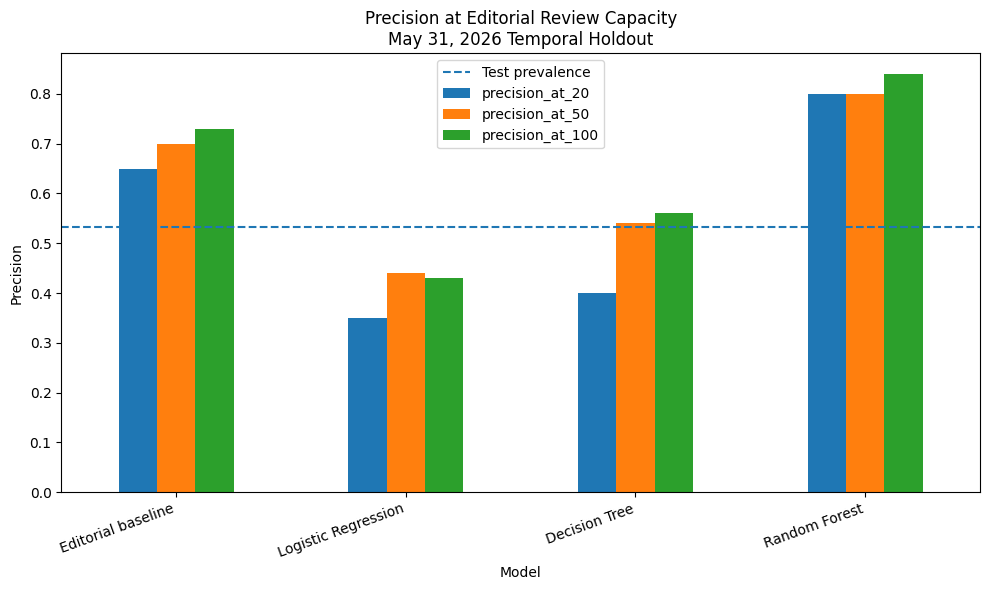

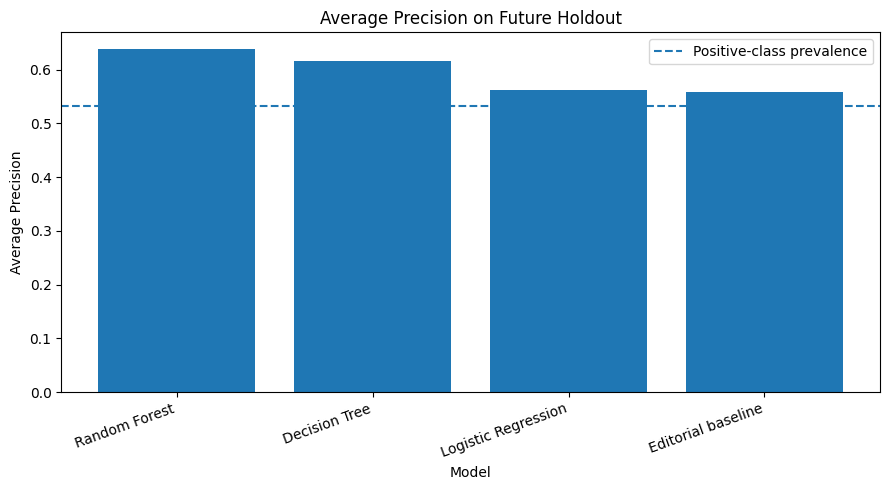


RANDOM FOREST FEATURE IMPORTANCE


,feature,importance
0,impressions_last30,0.143668
1,impression_change_30d,0.116944
2,avg_position_prev30,0.087186
3,ctr_last30,0.085544
4,impressions_90d,0.077061
5,impressions_prev30,0.076401
6,avg_position_last30,0.067451
7,click_change_30d,0.067272
8,ctr_90d,0.065221
9,position_change_30d,0.058816


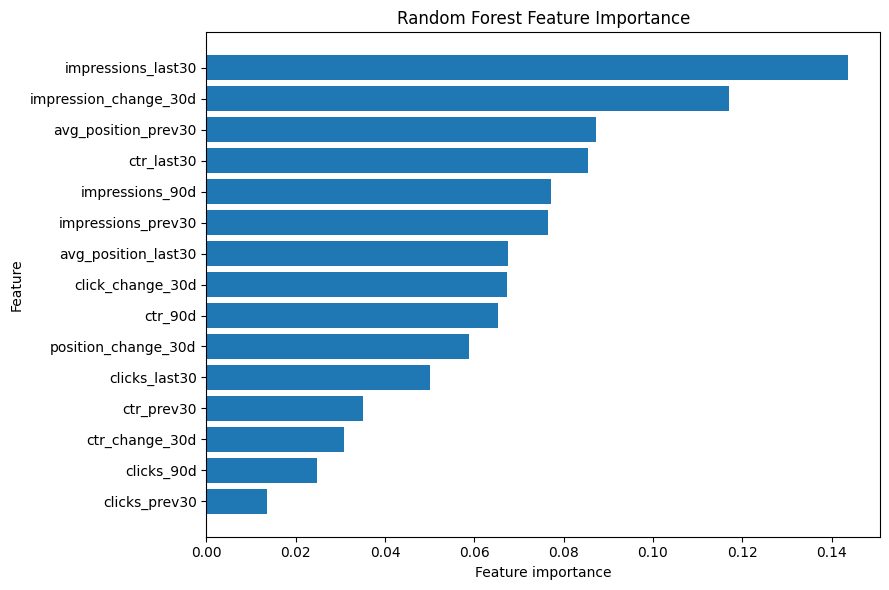


Scored test-set sample:


,decision_date,client_hash_id,content_hash_id,impressions_last30,impression_change_30d,future_impression_change,future_decline,baseline_score,logistic_probability,tree_probability,rf_probability
214644,2026-05-31,client_3ffa76342f366962,content_7f2dadfbfe673267,68.0,0.478261,-0.147059,0,0.000000,0.254389,0.124341,0.107111
214645,2026-05-31,client_3ffa76342f366962,content_924fcfa2714a8454,46.0,-0.220339,0.565217,0,0.848338,0.000703,0.084746,0.097442
214646,2026-05-31,client_3ffa76342f366962,content_75aa4945203fab36,57.0,-0.551181,0.175439,0,2.238039,0.414677,0.063241,0.080854
214647,2026-05-31,client_3ffa76342f366962,content_2995d2cec166177d,35.0,-0.078947,0.800000,0,0.282909,0.297692,0.014147,0.037564
214648,2026-05-31,client_3ffa76342f366962,content_ea47a9942c29eded,76.0,-0.296296,-0.263158,0,1.287053,0.001502,0.124341,0.182941


In [39]:
# ============================================================
# RESULTS — BASELINE + FIRST ML MODEL COMPARISON
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)


# ============================================================
# 1. DEFINE LEAKAGE-SAFE GSC FEATURE SET
# ============================================================

FEATURES = [
    # Overall historical search exposure
    "impressions_90d",
    "clicks_90d",

    # Recent 30-day performance
    "impressions_last30",
    "clicks_last30",

    # Previous 30-day performance
    "impressions_prev30",
    "clicks_prev30",

    # CTR
    "ctr_90d",
    "ctr_last30",
    "ctr_prev30",

    # Momentum
    "impression_change_30d",
    "click_change_30d",
    "ctr_change_30d",

    # Search position
    "avg_position_last30",
    "avg_position_prev30",
    "position_change_30d"
]

TARGET = "future_decline"


# ------------------------------------------------------------
# Safety check: future information must never be a feature
# ------------------------------------------------------------

FORBIDDEN_FUTURE_COLUMNS = {
    "impressions_future30",
    "clicks_future30",
    "future_impression_change",
    "future_decline"
}

assert not (
    set(FEATURES)
    & FORBIDDEN_FUTURE_COLUMNS
), "Leakage detected in feature list."


print("=" * 60)
print("MODEL FEATURE SET")
print("=" * 60)

print(f"Number of features: {len(FEATURES)}")

for feature in FEATURES:
    print(" -", feature)


# ============================================================
# 2. PREPARE TEMPORAL TRAIN / TEST DATA
# ============================================================

X_train = train_df[FEATURES].copy()
y_train = train_df[TARGET].copy()

X_test = test_df[FEATURES].copy()
y_test = test_df[TARGET].copy()


print("\n" + "=" * 60)
print("TEMPORAL TRAIN / TEST DATA")
print("=" * 60)

print(
    f"Training rows: "
    f"{len(X_train):,}"
)

print(
    f"Training positive rate: "
    f"{y_train.mean():.1%}"
)

print(
    f"Test rows: "
    f"{len(X_test):,}"
)

print(
    f"Test positive rate: "
    f"{y_test.mean():.1%}"
)


# ============================================================
# 3. CHECK MISSING VALUES
# ============================================================

missing_audit = pd.DataFrame({
    "feature": FEATURES,

    "train_missing_pct": [
        100 * X_train[col].isna().mean()
        for col in FEATURES
    ],

    "test_missing_pct": [
        100 * X_test[col].isna().mean()
        for col in FEATURES
    ]
})

print("\n" + "=" * 60)
print("MISSING-VALUE AUDIT")
print("=" * 60)

display(missing_audit)


# ============================================================
# 4. DEFINE EDITORIAL BASELINE
#
# Baseline intuition:
#
# Pages are more urgent when:
#   1. impressions are already declining, and
#   2. the page has meaningful search exposure.
#
# baseline_score =
#
#   historical decline magnitude
#   ×
#   log-scaled recent exposure
#
# No future information is used.
# ============================================================

def make_baseline_score(df):
    """
    Transparent non-ML editorial baseline.

    Higher score means:
        stronger recent decline
        AND
        greater recent search exposure.
    """

    decline_signal = np.maximum(
        -df["impression_change_30d"],
        0
    )

    exposure_signal = np.log1p(
        df["impressions_last30"]
    )

    score = (
        decline_signal
        *
        exposure_signal
    )

    return score


test_baseline_score = make_baseline_score(
    test_df
)


print("\n" + "=" * 60)
print("BASELINE SCORE")
print("=" * 60)

print(
    pd.Series(
        test_baseline_score
    ).describe()
)


# ============================================================
# 5. EVALUATION FUNCTIONS
# ============================================================

def precision_at_k(
    y_true,
    scores,
    k
):
    """
    Precision among the k highest-scored pages.
    """

    result = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "score": np.asarray(scores)
    })

    result = result.sort_values(
        "score",
        ascending=False
    )

    top_k = result.head(k)

    return top_k["y_true"].mean()


def recall_at_k(
    y_true,
    scores,
    k
):
    """
    Fraction of all true decline pages captured
    in the top-k recommendation queue.
    """

    result = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "score": np.asarray(scores)
    })

    result = result.sort_values(
        "score",
        ascending=False
    )

    top_k_positives = (
        result
        .head(k)["y_true"]
        .sum()
    )

    total_positives = result[
        "y_true"
    ].sum()

    if total_positives == 0:
        return np.nan

    return (
        top_k_positives
        /
        total_positives
    )


def evaluate_ranking_model(
    model_name,
    y_true,
    scores,
    top_k_values=(20, 50, 100)
):
    """
    Evaluate ranking/classification performance
    on one fixed test set.
    """

    row = {
        "model": model_name,

        "average_precision":
            average_precision_score(
                y_true,
                scores
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                scores
            )
    }

    for k in top_k_values:

        row[f"precision_at_{k}"] = (
            precision_at_k(
                y_true,
                scores,
                k
            )
        )

        row[f"recall_at_{k}"] = (
            recall_at_k(
                y_true,
                scores,
                k
            )
        )

    return row


# ============================================================
# 6. EVALUATE TRANSPARENT BASELINE
# ============================================================

results = []

baseline_result = evaluate_ranking_model(
    model_name="Editorial baseline",
    y_true=y_test,
    scores=test_baseline_score,
    top_k_values=TOP_K_VALUES
)

results.append(
    baseline_result
)


# ============================================================
# 7. LOGISTIC REGRESSION
#
# Median imputation handles missing position values.
# Scaling is important for logistic regression because
# the features have very different numerical ranges.
# ============================================================

logistic_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        ),

        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)


print("\nTraining Logistic Regression...")

logistic_model.fit(
    X_train,
    y_train
)

logistic_scores = (
    logistic_model
    .predict_proba(X_test)[:, 1]
)


logistic_result = evaluate_ranking_model(
    model_name="Logistic Regression",
    y_true=y_test,
    scores=logistic_scores,
    top_k_values=TOP_K_VALUES
)

results.append(
    logistic_result
)


# ============================================================
# 8. DECISION TREE
#
# A shallow tree is deliberately used to reduce overfitting
# and keep the model interpretable.
# ============================================================

tree_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "model",
            DecisionTreeClassifier(
                max_depth=6,
                min_samples_leaf=100,
                random_state=RANDOM_STATE
            )
        )
    ]
)


print("Training Decision Tree...")

tree_model.fit(
    X_train,
    y_train
)

tree_scores = (
    tree_model
    .predict_proba(X_test)[:, 1]
)


tree_result = evaluate_ranking_model(
    model_name="Decision Tree",
    y_true=y_test,
    scores=tree_scores,
    top_k_values=TOP_K_VALUES
)

results.append(
    tree_result
)


# ============================================================
# 9. RANDOM FOREST
#
# Restrict depth and leaf size so the model does not simply
# memorize individual historical observations.
# ============================================================

rf_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=50,

                n_jobs=-1,

                random_state=RANDOM_STATE
            )
        )
    ]
)


print("Training Random Forest...")

rf_model.fit(
    X_train,
    y_train
)

rf_scores = (
    rf_model
    .predict_proba(X_test)[:, 1]
)


rf_result = evaluate_ranking_model(
    model_name="Random Forest",
    y_true=y_test,
    scores=rf_scores,
    top_k_values=TOP_K_VALUES
)

results.append(
    rf_result
)


# ============================================================
# 10. COMBINE RESULTS
# ============================================================

results_df = pd.DataFrame(
    results
)


# Convert metrics to percentages for easier reading
percentage_columns = [
    "average_precision",
    "roc_auc",
    "precision_at_20",
    "recall_at_20",
    "precision_at_50",
    "recall_at_50",
    "precision_at_100",
    "recall_at_100"
]


results_display = (
    results_df.copy()
)

for col in percentage_columns:

    results_display[col] = (
        100 *
        results_display[col]
    )


print("\n" + "=" * 60)
print("MODEL VS BASELINE — MAY 31 HOLDOUT")
print("=" * 60)

display(
    results_display.round(2)
)


# ============================================================
# 11. SIMPLE RANDOM-RANKING REFERENCE
#
# Since 53.2% of test pages decline, a random ranking would
# have expected precision approximately equal to prevalence.
# This is NOT a trained model; it is a reference point.
# ============================================================

test_prevalence = (
    y_test.mean()
)


print(
    "\nTest-set decline prevalence "
    f"(random-ranking precision reference): "
    f"{test_prevalence:.1%}"
)


# ============================================================
# 12. IDENTIFY BEST MODEL BY AVERAGE PRECISION
# ============================================================

best_row = (
    results_df
    .sort_values(
        "average_precision",
        ascending=False
    )
    .iloc[0]
)


print("\n" + "=" * 60)
print("BEST MODEL")
print("=" * 60)

print(
    "Best by Average Precision:",
    best_row["model"]
)

print(
    f"Average Precision: "
    f"{best_row['average_precision']:.3f}"
)

print(
    f"Precision@50: "
    f"{best_row['precision_at_50']:.3f}"
)


# ============================================================
# 13. PRECISION@K COMPARISON CHART
# ============================================================

precision_plot_df = (
    results_df[
        [
            "model",
            "precision_at_20",
            "precision_at_50",
            "precision_at_100"
        ]
    ]
    .set_index("model")
)


ax = precision_plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.axhline(
    y=test_prevalence,
    linestyle="--",
    label="Test prevalence"
)

plt.ylabel("Precision")
plt.xlabel("Model")

plt.title(
    "Precision at Editorial Review Capacity\n"
    "May 31, 2026 Temporal Holdout"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 14. AVERAGE PRECISION COMPARISON
# ============================================================

ap_plot_df = (
    results_df[
        [
            "model",
            "average_precision"
        ]
    ]
    .sort_values(
        "average_precision",
        ascending=False
    )
)


plt.figure(
    figsize=(9, 5)
)

plt.bar(
    ap_plot_df["model"],
    ap_plot_df["average_precision"]
)

plt.axhline(
    y=test_prevalence,
    linestyle="--",
    label="Positive-class prevalence"
)

plt.ylabel(
    "Average Precision"
)

plt.xlabel(
    "Model"
)

plt.title(
    "Average Precision on Future Holdout"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 15. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_classifier = (
    rf_model
    .named_steps["model"]
)


rf_importance_df = pd.DataFrame({
    "feature": FEATURES,

    "importance":
        rf_classifier.feature_importances_
})


rf_importance_df = (
    rf_importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 60)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)

display(
    rf_importance_df
)


plt.figure(
    figsize=(9, 6)
)

plt.barh(
    rf_importance_df["feature"][::-1],
    rf_importance_df["importance"][::-1]
)

plt.xlabel(
    "Feature importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.tight_layout()
plt.show()


# ============================================================
# 16. BUILD TEST-SET SCORE TABLE
#
# Keep this table because it will later become the basis for
# the ranked editorial recommendation queue.
# ============================================================

scored_test_df = (
    test_df.copy()
)


scored_test_df[
    "baseline_score"
] = np.asarray(
    test_baseline_score
)


scored_test_df[
    "logistic_probability"
] = logistic_scores


scored_test_df[
    "tree_probability"
] = tree_scores


scored_test_df[
    "rf_probability"
] = rf_scores


print("\nScored test-set sample:")

display(
    scored_test_df[
        [
            "decision_date",
            "client_hash_id",
            "content_hash_id",
            "impressions_last30",
            "impression_change_30d",
            "future_impression_change",
            "future_decline",
            "baseline_score",
            "logistic_probability",
            "tree_probability",
            "rf_probability"
        ]
    ]
    .head()
)

## 5. Limitations

*What this work cannot claim.*

This analysis should be interpreted as a decision-support study rather than evidence that a content refresh will causally improve search performance. The model predicts whether a page is likely to experience a meaningful decline in search impressions, but it does not estimate the effect of any specific editorial intervention. Pages ranked highly by the model may therefore warrant review, but the analysis cannot prove that refreshing, expanding, pruning, or otherwise modifying those pages will cause recovery.

The modeling population is also restricted to pages with sufficient observable Google Search Console coverage. Pages were required to have at least 20 observed days in the previous 30-day, recent 30-day, and future 30-day windows. This filtering reduces the risk of confusing missing observations with actual performance decline, but it also means that pages with sparse or intermittent reporting are underrepresented in the final dataset.

A substantial temporal shift was observed across the decision dates. The proportion of pages labeled as experiencing at least a 30% future impression decline increased from 15.5% on February 28 to 40.4% on March 31, 44.1% on April 30, and 53.2% on the May 31 holdout. As a result, the test period is materially different from the earlier training periods. This makes the evaluation more realistic, but it also suggests that model performance may vary when the overall search environment or client mix changes over time.

The final Random Forest achieved an Average Precision of 63.76% and ROC-AUC of 63.27% on the May holdout. These values indicate moderate overall discrimination rather than near-perfect prediction. The strongest result was concentrated at the top of the ranked queue, where the Random Forest achieved 80% Precision@50 and 84% Precision@100, compared with a 53.2% positive-class prevalence. The model should therefore be viewed primarily as a prioritization tool for limited editorial review capacity rather than a classifier that can reliably label every page.

Recall@K is necessarily very small because the test set contains 45,548 decline-positive pages while the recommendation queues contain only 20, 50, or 100 pages. For this use case, low Recall@K does not by itself imply poor ranking quality; Precision@K is more directly aligned with the decision problem of selecting a small number of pages for review.

The current feature set consists only of historical GSC-derived performance signals. This improves point-in-time safety, but it excludes potentially useful content characteristics, query composition, and engagement information. Static fields from `dim_content` were not added at this stage because their historical point-in-time validity was not established for every decision date. Adding such variables without confirming when they were measured could introduce temporal leakage.

Finally, Random Forest feature importance should not be interpreted causally. For example, `impressions_last30`, `impression_change_30d`, and search-position variables were among the most influential features, but their importance only indicates that they contributed to the model's predictions. It does not demonstrate that changing any of these variables would directly prevent future decline.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

High-exposure threshold (75th percentile): 2112.0

TOP 20 EDITORIAL REVIEW RECOMMENDATIONS


,rank,client_hash_id,content_hash_id,opportunity_score,decline_probability,confidence,recommended_action,reason_codes,impressions_last30,impressions_prev30,impression_change_30d,clicks_last30,click_change_30d,avg_position_last30,position_change_30d,ctr_last30,ctr_change_30d
0,1,client_23a62021009f63c4,content_f7aa0fc65d7cde14,100.00,0.703,MEDIUM,REFRESH,STRONG_VISIBILITY_DECLINE; HIGH_SEARCH_EXPOSURE,39492.0,59628.0,-0.338,5.0,0.667,29.97,1.93,0.0001,0.0001
1,2,client_e547b89c05043229,content_5e20282db1d5b814,99.86,0.744,MEDIUM,REFRESH,STRONG_VISIBILITY_DECLINE; STRONG_CLICK_DECLIN...,21655.0,89759.0,-0.759,13.0,-0.500,2.68,0.39,0.0006,0.0003
2,3,client_23a62021009f63c4,content_96e6613b42b52c42,99.61,0.722,MEDIUM,REFRESH,STRONG_VISIBILITY_DECLINE; STRONG_CLICK_DECLIN...,28614.0,56050.0,-0.489,1.0,-0.500,50.51,4.01,0.0000,-0.0000
3,4,client_23a62021009f63c4,content_4656fc1cadffa6d1,97.68,0.698,MEDIUM,EXPAND_OR_REVIEW,STRONG_VISIBILITY_DECLINE; STRONG_CLICK_DECLIN...,33137.0,61371.0,-0.460,3.0,-0.400,25.10,-5.95,0.0001,0.0000
4,5,client_23a62021009f63c4,content_e3fedb72068586e2,97.33,0.747,MEDIUM,REFRESH,STRONG_VISIBILITY_DECLINE; STRONG_CLICK_DECLIN...,16098.0,30765.0,-0.477,0.0,-1.000,45.78,4.28,0.0000,-0.0001
5,6,client_23a62021009f63c4,content_164c1f53f13bcee1,96.97,0.694,MEDIUM,EXPAND_OR_REVIEW,STRONG_VISIBILITY_DECLINE; HIGH_SEARCH_EXPOSURE,32607.0,77554.0,-0.580,3.0,0.000,25.51,-1.33,0.0001,0.0001
6,7,client_23a62021009f63c4,content_8239af50cfd75d26,96.79,0.728,MEDIUM,REFRESH,VISIBILITY_DECLINE; POSITION_DETERIORATION; HI...,19685.0,25662.0,-0.233,3.0,2.000,45.36,5.80,0.0002,0.0001
7,8,client_23a62021009f63c4,content_ab91e088440ace78,96.70,0.724,MEDIUM,REFRESH,STRONG_VISIBILITY_DECLINE; STRONG_CLICK_DECLIN...,20632.0,53884.0,-0.617,2.0,-0.333,48.11,4.32,0.0001,0.0000
8,9,client_23a62021009f63c4,content_a872fe0e05536717,96.65,0.719,MEDIUM,REFRESH,STRONG_VISIBILITY_DECLINE; STRONG_CLICK_DECLIN...,22164.0,34075.0,-0.350,3.0,-0.400,31.02,-1.03,0.0001,-0.0000
9,10,client_23a62021009f63c4,content_066c2291283a5200,96.30,0.734,MEDIUM,REFRESH,STRONG_VISIBILITY_DECLINE; HIGH_SEARCH_EXPOSURE,17262.0,27476.0,-0.372,1.0,1.000,39.45,2.70,0.0001,0.0001



Action distribution:


,recommended_action,pages,pct_of_pages
0,MONITOR,79733,93.19
1,EXPAND_OR_REVIEW,5485,6.41
2,REFRESH,341,0.40
3,PROTECT,3,0.00



Top-50 recommendation actions:


,recommended_action,pages
0,REFRESH,33
1,EXPAND_OR_REVIEW,16
2,PROTECT,1



OPPORTUNITY-SCORE QUEUE VALIDATION


,k,true_declines,precision_at_k,precision_at_k_pct
0,20,18,0.90,90.0
1,50,46,0.92,92.0
2,100,89,0.89,89.0


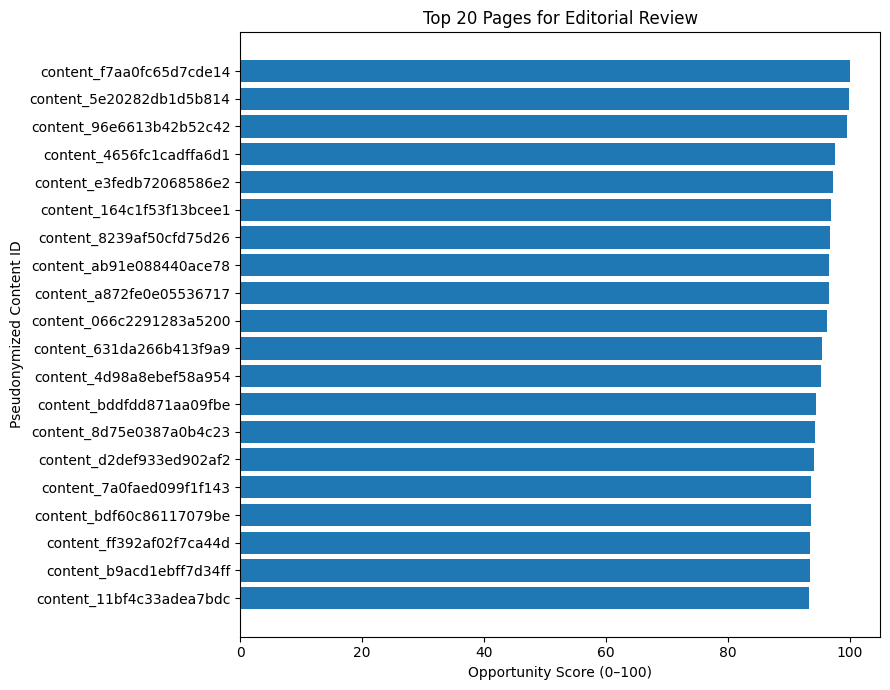


Saved recommendation queue to: ranked_recommendations.csv


In [40]:
# ============================================================
# RANKED RECOMMENDATIONS — EDITORIAL ACTION QUEUE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. START FROM THE SCORED MAY HOLDOUT
# ============================================================

recommendations_df = (
    scored_test_df.copy()
)


# ============================================================
# 2. SELECT FINAL MODEL
#
# Random Forest was the strongest model on the May holdout:
#
# Average Precision ≈ 0.638
# Precision@50     ≈ 0.800
# Precision@100    ≈ 0.840
# ============================================================

recommendations_df[
    "decline_probability"
] = recommendations_df[
    "rf_probability"
]


# ============================================================
# 3. CREATE EXPOSURE WEIGHT
#
# log1p compresses very large impression counts so that
# high-volume pages matter without completely dominating
# the ranking.
# ============================================================

recommendations_df[
    "exposure_weight"
] = np.log1p(
    recommendations_df[
        "impressions_last30"
    ]
)


# Normalize exposure to approximately 0–1
max_exposure = (
    recommendations_df[
        "exposure_weight"
    ].max()
)

recommendations_df[
    "exposure_weight_norm"
] = (
    recommendations_df[
        "exposure_weight"
    ]
    /
    max_exposure
)


# ============================================================
# 4. BUILD OPPORTUNITY SCORE
#
# Combines:
#     modeled future decline risk
#     ×
#     recent search exposure
#
# Scale to 0–100 for readability.
# ============================================================

recommendations_df[
    "opportunity_score_raw"
] = (
    recommendations_df[
        "decline_probability"
    ]
    *
    recommendations_df[
        "exposure_weight_norm"
    ]
)


max_opportunity = (
    recommendations_df[
        "opportunity_score_raw"
    ].max()
)


recommendations_df[
    "opportunity_score"
] = (
    100
    *
    recommendations_df[
        "opportunity_score_raw"
    ]
    /
    max_opportunity
)


# ============================================================
# 5. BUILD REASON CODES
#
# These are descriptive explanations based only on
# observable historical signals.
# ============================================================

def make_reason_codes(row):

    reasons = []

    # --------------------------------------------------------
    # Strong impression decline
    # --------------------------------------------------------

    if row[
        "impression_change_30d"
    ] <= -0.30:

        reasons.append(
            "STRONG_VISIBILITY_DECLINE"
        )

    elif row[
        "impression_change_30d"
    ] < 0:

        reasons.append(
            "VISIBILITY_DECLINE"
        )


    # --------------------------------------------------------
    # Click decline
    # --------------------------------------------------------

    if row[
        "click_change_30d"
    ] <= -0.30:

        reasons.append(
            "STRONG_CLICK_DECLINE"
        )

    elif row[
        "click_change_30d"
    ] < 0:

        reasons.append(
            "CLICK_DECLINE"
        )


    # --------------------------------------------------------
    # Position deterioration
    #
    # Positive position change means the numerical
    # average position became worse.
    # --------------------------------------------------------

    if (
        pd.notna(
            row[
                "position_change_30d"
            ]
        )
        and
        row[
            "position_change_30d"
        ] >= 3
    ):

        reasons.append(
            "POSITION_DETERIORATION"
        )


    # --------------------------------------------------------
    # High recent exposure
    #
    # Use distribution-based thresholds instead of arbitrary
    # absolute impression values.
    # --------------------------------------------------------

    if row[
        "impressions_last30"
    ] >= high_exposure_threshold:

        reasons.append(
            "HIGH_SEARCH_EXPOSURE"
        )


    # --------------------------------------------------------
    # CTR weakening
    # --------------------------------------------------------

    if row[
        "ctr_change_30d"
    ] < 0:

        reasons.append(
            "CTR_WEAKENING"
        )


    # If no strong historical warning signal is present,
    # retain a general model-based reason.
    if len(reasons) == 0:

        reasons.append(
            "MODEL_IDENTIFIED_RISK"
        )

    return "; ".join(
        reasons
    )


# ============================================================
# 6. DEFINE DATA-DRIVEN EXPOSURE THRESHOLD
#
# Top 25% of recent-impression distribution is treated
# as relatively high exposure.
# ============================================================

high_exposure_threshold = (
    recommendations_df[
        "impressions_last30"
    ]
    .quantile(0.75)
)


print(
    "High-exposure threshold "
    "(75th percentile):",
    round(
        high_exposure_threshold,
        2
    )
)


recommendations_df[
    "reason_codes"
] = (
    recommendations_df.apply(
        make_reason_codes,
        axis=1
    )
)


# ============================================================
# 7. ASSIGN ACTION RECOMMENDATIONS
#
# These are review recommendations, NOT causal claims.
# ============================================================

def assign_action(row):

    risk = row[
        "decline_probability"
    ]

    exposure = row[
        "impressions_last30"
    ]

    imp_change = row[
        "impression_change_30d"
    ]

    pos_change = row[
        "position_change_30d"
    ]

    ctr_change = row[
        "ctr_change_30d"
    ]


    # --------------------------------------------------------
    # REFRESH
    #
    # High predicted risk + existing historical deterioration
    # --------------------------------------------------------

    if (
        risk >= 0.70
        and
        (
            imp_change <= -0.20
            or
            (
                pd.notna(pos_change)
                and
                pos_change >= 2
            )
        )
    ):

        return "REFRESH"


    # --------------------------------------------------------
    # PROTECT
    #
    # High exposure + high predicted risk,
    # but performance has not strongly deteriorated yet.
    # --------------------------------------------------------

    if (
        risk >= 0.70
        and
        exposure >= high_exposure_threshold
        and
        imp_change > -0.20
    ):

        return "PROTECT"


    # --------------------------------------------------------
    # EXPAND / REVIEW
    #
    # Moderate-to-high risk accompanied by weakening CTR
    # or moderate visibility decline.
    # --------------------------------------------------------

    if (
        risk >= 0.55
        and
        (
            imp_change < 0
            or
            ctr_change < 0
        )
    ):

        return "EXPAND_OR_REVIEW"


    # --------------------------------------------------------
    # MONITOR
    # --------------------------------------------------------

    return "MONITOR"


recommendations_df[
    "recommended_action"
] = (
    recommendations_df.apply(
        assign_action,
        axis=1
    )
)


# ============================================================
# 8. ASSIGN CONFIDENCE BAND
#
# These bands describe model-score strength only.
# They are not calibrated causal probabilities.
# ============================================================

def confidence_band(probability):

    if probability >= 0.75:
        return "HIGH"

    elif probability >= 0.60:
        return "MEDIUM"

    else:
        return "LOW"


recommendations_df[
    "confidence"
] = (
    recommendations_df[
        "decline_probability"
    ]
    .apply(
        confidence_band
    )
)


# ============================================================
# 9. SORT INTO FINAL EDITORIAL QUEUE
# ============================================================

recommendations_df = (
    recommendations_df
    .sort_values(
        [
            "opportunity_score",
            "decline_probability"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


recommendations_df[
    "rank"
] = (
    np.arange(
        1,
        len(
            recommendations_df
        ) + 1
    )
)


# ============================================================
# 10. PUBLIC-SAFE OUTPUT COLUMNS
#
# Keep only pseudonymized identifiers.
# ============================================================

recommendation_columns = [
    "rank",

    "client_hash_id",
    "content_hash_id",

    "opportunity_score",
    "decline_probability",

    "confidence",
    "recommended_action",

    "reason_codes",

    "impressions_last30",
    "impressions_prev30",

    "impression_change_30d",

    "clicks_last30",
    "click_change_30d",

    "avg_position_last30",
    "position_change_30d",

    "ctr_last30",
    "ctr_change_30d"
]


ranked_recommendations = (
    recommendations_df[
        recommendation_columns
    ]
    .copy()
)


# ============================================================
# 11. DISPLAY TOP 20 RECOMMENDATIONS
# ============================================================

print(
    "\n" + "=" * 60
)

print(
    "TOP 20 EDITORIAL REVIEW RECOMMENDATIONS"
)

print(
    "=" * 60
)


display(
    ranked_recommendations
    .head(20)
    .round(
        {
            "opportunity_score": 2,
            "decline_probability": 3,
            "impression_change_30d": 3,
            "click_change_30d": 3,
            "avg_position_last30": 2,
            "position_change_30d": 2,
            "ctr_last30": 4,
            "ctr_change_30d": 4
        }
    )
)


# ============================================================
# 12. ACTION DISTRIBUTION
# ============================================================

action_summary = (
    ranked_recommendations[
        "recommended_action"
    ]
    .value_counts()
    .rename_axis(
        "recommended_action"
    )
    .reset_index(
        name="pages"
    )
)


action_summary[
    "pct_of_pages"
] = (
    100
    *
    action_summary[
        "pages"
    ]
    /
    len(
        ranked_recommendations
    )
)


print(
    "\nAction distribution:"
)

display(
    action_summary.round(2)
)


# ============================================================
# 13. TOP-50 ACTION DISTRIBUTION
# ============================================================

top50_action_summary = (
    ranked_recommendations
    .head(50)[
        "recommended_action"
    ]
    .value_counts()
    .rename_axis(
        "recommended_action"
    )
    .reset_index(
        name="pages"
    )
)


print(
    "\nTop-50 recommendation actions:"
)

display(
    top50_action_summary
)


# ============================================================
# 14. VALIDATE TOP-K QUEUE AGAINST OBSERVED OUTCOME
#
# This is evaluation only.
#
# future_decline was NOT used to create the ranking.
# ============================================================

evaluation_queue = (
    recommendations_df[
        [
            "rank",
            "opportunity_score",
            "future_decline"
        ]
    ]
)


queue_validation = []


for k in [
    20,
    50,
    100
]:

    top_k = (
        evaluation_queue
        .head(k)
    )

    queue_validation.append(
        {
            "k": k,

            "true_declines":
                int(
                    top_k[
                        "future_decline"
                    ].sum()
                ),

            "precision_at_k":
                top_k[
                    "future_decline"
                ].mean()
        }
    )


queue_validation_df = (
    pd.DataFrame(
        queue_validation
    )
)


queue_validation_df[
    "precision_at_k_pct"
] = (
    100
    *
    queue_validation_df[
        "precision_at_k"
    ]
)


print(
    "\n" + "=" * 60
)

print(
    "OPPORTUNITY-SCORE QUEUE VALIDATION"
)

print(
    "=" * 60
)


display(
    queue_validation_df
)


# ============================================================
# 15. VISUALIZE TOP-20 OPPORTUNITY SCORES
# ============================================================

top20 = (
    ranked_recommendations
    .head(20)
    .sort_values(
        "opportunity_score",
        ascending=True
    )
)


plt.figure(
    figsize=(9, 7)
)


plt.barh(
    top20[
        "content_hash_id"
    ],

    top20[
        "opportunity_score"
    ]
)


plt.xlabel(
    "Opportunity Score (0–100)"
)

plt.ylabel(
    "Pseudonymized Content ID"
)

plt.title(
    "Top 20 Pages for Editorial Review"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. EXPORT PUBLIC-SAFE RECOMMENDATION QUEUE
#
# Optional artifact for the final repo.
# ============================================================

output_path = (
    "ranked_recommendations.csv"
)


ranked_recommendations.to_csv(
    output_path,
    index=False
)


print(
    f"\nSaved recommendation queue to: "
    f"{output_path}"
)

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Saving final paper artifacts to: artifacts
Saved table: artifacts/table_data_monthly_partition_counts.csv
Saved table: artifacts/table_data_monthly_coverage.csv
Saved table: artifacts/table_data_overall_coverage.csv
Saved table: artifacts/table_data_gsc_ga4_availability.csv
Saved table: artifacts/table_data_warehouse_table_sizes.csv
Saved table: artifacts/table_schema_dim_clients.csv
Saved table: artifacts/table_schema_dim_content.csv
Saved table: artifacts/table_schema_daily_performance.csv
Saved table: artifacts/table_schema_query_90d.csv
Saved table: artifacts/table_methodology_snapshot_summary.csv
Saved table: artifacts/table_methodology_target_distribution.csv
Saved table: artifacts/table_methodology_train_test_split.csv
Saved table: artifacts/table_results_missing_value_audit.csv
Saved table: artifacts/table_results_model_comparison.csv
Saved table: artifacts/table_results_rf_feature_importance.csv
Saved table: artifacts/table_results_scored_holdout_sample.csv
Saved table: artifa

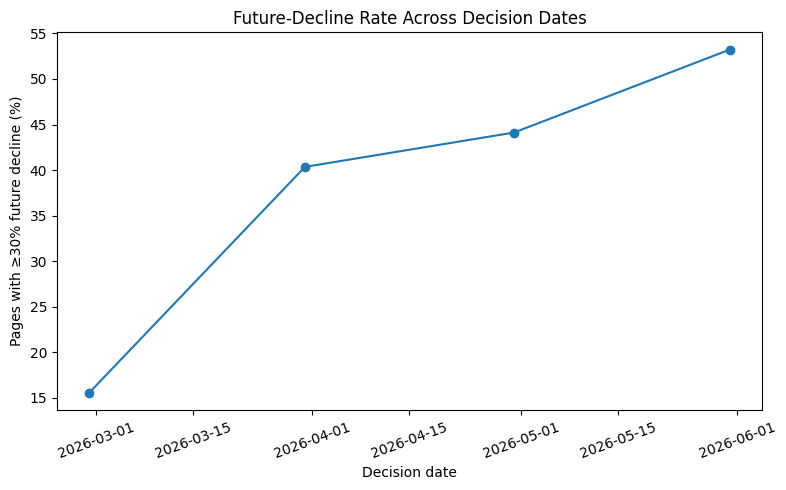

Saved figure: artifacts/figure_01_decline_rate_over_time.png


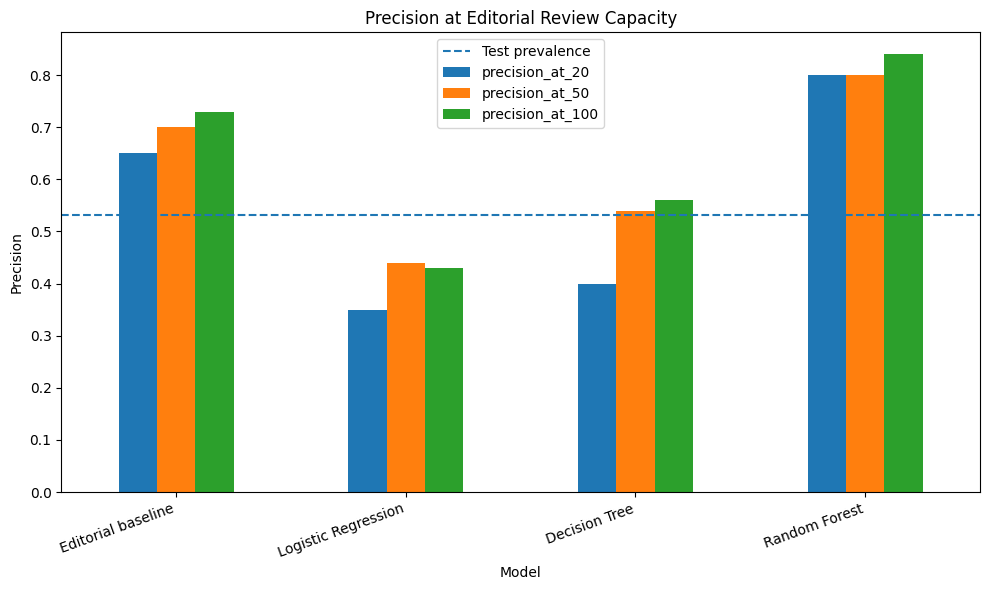

Saved figure: artifacts/figure_02_precision_at_k.png


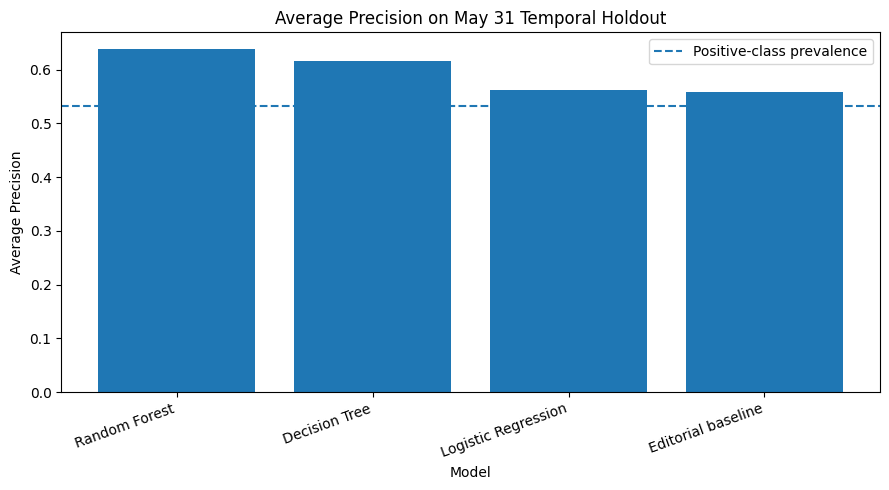

Saved figure: artifacts/figure_03_average_precision.png


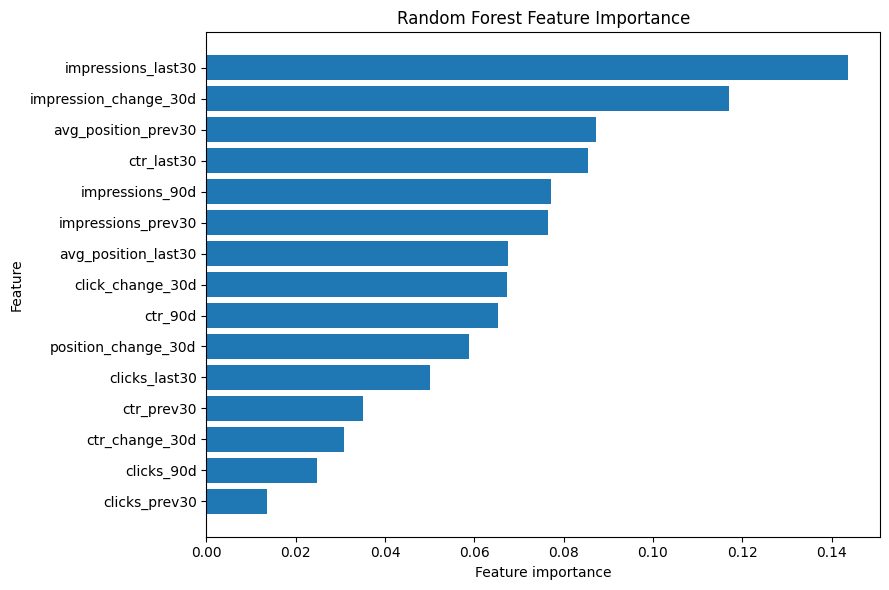

Saved figure: artifacts/figure_04_rf_feature_importance.png


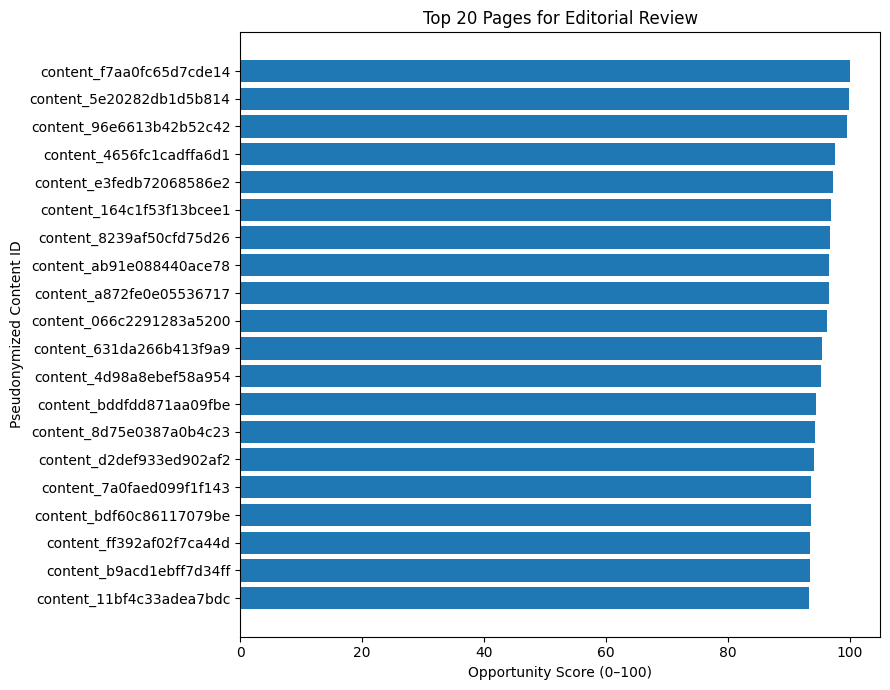

Saved figure: artifacts/figure_05_top20_opportunity_scores.png


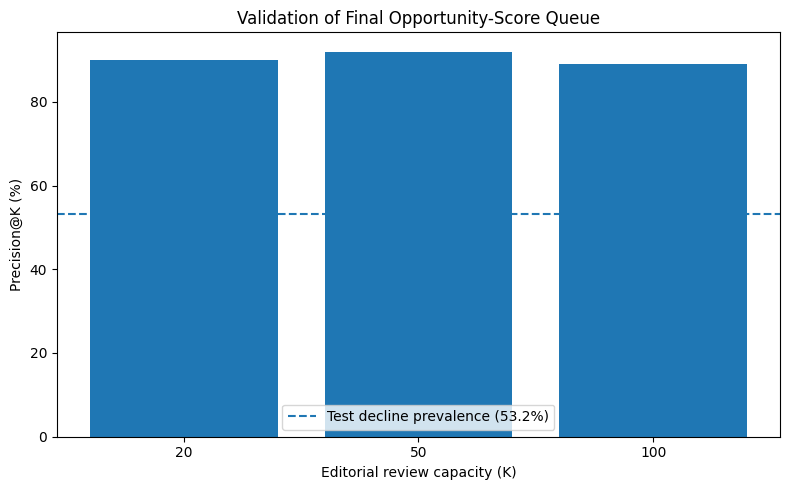

Saved figure: artifacts/figure_06_opportunity_queue_precision.png

KEY RESULTS FOR THE DEPLOYED PAPER


,metric,value
0,Total modeling observations,"300,206"
1,Training observations,"214,644"
2,Holdout observations,"85,562"
3,Holdout decline prevalence,53.2%
4,Random Forest Average Precision,63.76%
5,Random Forest ROC-AUC,63.27%
6,Random Forest Precision@50,80.0%
7,Editorial baseline Precision@50,70.0%
8,Opportunity queue Precision@20,90.0%
9,Opportunity queue Precision@50,92.0%


Saved table: artifacts/table_paper_key_results.csv

FINAL ARTIFACT MANIFEST
 - figure_01_decline_rate_over_time.png
 - figure_02_precision_at_k.png
 - figure_03_average_precision.png
 - figure_04_rf_feature_importance.png
 - figure_05_top20_opportunity_scores.png
 - figure_06_opportunity_queue_precision.png
 - ranked_recommendations.csv
 - table_data_gsc_ga4_availability.csv
 - table_data_monthly_coverage.csv
 - table_data_monthly_partition_counts.csv
 - table_data_overall_coverage.csv
 - table_data_warehouse_table_sizes.csv
 - table_methodology_snapshot_summary.csv
 - table_methodology_target_distribution.csv
 - table_methodology_train_test_split.csv
 - table_paper_key_results.csv
 - table_recommendations_action_distribution.csv
 - table_recommendations_queue_validation.csv
 - table_recommendations_top20.csv
 - table_recommendations_top50_actions.csv
 - table_results_missing_value_audit.csv
 - table_results_model_comparison.csv
 - table_results_rf_feature_importance.csv
 - table_resul

In [41]:
# ============================================================
# 7. ARTIFACTS THE PAPER EMBEDS
#
# Export the final public-safe tables and figures used in the
# deployed research paper.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CREATE ARTIFACT DIRECTORY
# ============================================================

# Works whether the notebook is executed from the repository
# root or directly from another environment such as Colab.

if os.path.isdir("work"):
    ARTIFACT_DIR = "work/artifacts"
else:
    ARTIFACT_DIR = "artifacts"

os.makedirs(
    ARTIFACT_DIR,
    exist_ok=True
)

print(
    f"Saving final paper artifacts to: "
    f"{ARTIFACT_DIR}"
)


# ============================================================
# 2. HELPER FUNCTION FOR TABLE EXPORTS
# ============================================================

def save_table(
    table,
    filename,
    index=False
):
    """
    Save a DataFrame or Series as a CSV artifact.
    """

    if isinstance(
        table,
        pd.Series
    ):
        table = (
            table
            .rename("value")
            .reset_index()
        )

    path = os.path.join(
        ARTIFACT_DIR,
        filename
    )

    table.to_csv(
        path,
        index=index
    )

    print(
        f"Saved table: {path}"
    )

    return path


# ============================================================
# 3. DATA-SECTION TABLES
# ============================================================

save_table(
    partition_counts_df,
    "table_data_monthly_partition_counts.csv"
)

save_table(
    coverage_df,
    "table_data_monthly_coverage.csv"
)

save_table(
    overall_coverage,
    "table_data_overall_coverage.csv"
)

save_table(
    availability_df,
    "table_data_gsc_ga4_availability.csv"
)

save_table(
    table_sizes,
    "table_data_warehouse_table_sizes.csv"
)


# Schema tables used during the data audit

save_table(
    dim_clients_schema,
    "table_schema_dim_clients.csv"
)

save_table(
    dim_content_schema,
    "table_schema_dim_content.csv"
)

save_table(
    daily_schema,
    "table_schema_daily_performance.csv"
)

save_table(
    query_schema,
    "table_schema_query_90d.csv"
)


# ============================================================
# 4. METHODOLOGY TABLES
# ============================================================

save_table(
    snapshot_summary,
    "table_methodology_snapshot_summary.csv"
)


# Rebuild target-distribution table into a cleaner form

target_distribution_table = (
    model_df[
        "future_decline"
    ]
    .value_counts()
    .sort_index()
    .rename(
        index={
            0: "No meaningful decline",
            1: "Meaningful decline"
        }
    )
    .rename_axis(
        "target_class"
    )
    .reset_index(
        name="observations"
    )
)

target_distribution_table[
    "percentage"
] = (
    100
    *
    target_distribution_table[
        "observations"
    ]
    /
    target_distribution_table[
        "observations"
    ].sum()
)

save_table(
    target_distribution_table,
    "table_methodology_target_distribution.csv"
)


# Train/test split summary

train_test_summary = pd.DataFrame(
    {
        "split": [
            "Training",
            "Temporal holdout"
        ],

        "observations": [
            len(train_df),
            len(test_df)
        ],

        "decline_rate_pct": [
            100
            * train_df[
                "future_decline"
            ].mean(),

            100
            * test_df[
                "future_decline"
            ].mean()
        ]
    }
)

save_table(
    train_test_summary,
    "table_methodology_train_test_split.csv"
)


# ============================================================
# 5. RESULTS TABLES
# ============================================================

save_table(
    missing_audit,
    "table_results_missing_value_audit.csv"
)

save_table(
    results_display,
    "table_results_model_comparison.csv"
)

save_table(
    rf_importance_df,
    "table_results_rf_feature_importance.csv"
)


# Public-safe scored sample only

scored_test_sample = (
    scored_test_df[
        [
            "decision_date",
            "client_hash_id",
            "content_hash_id",
            "impressions_last30",
            "impression_change_30d",
            "future_impression_change",
            "future_decline",
            "baseline_score",
            "logistic_probability",
            "tree_probability",
            "rf_probability"
        ]
    ]
    .head(20)
    .copy()
)

save_table(
    scored_test_sample,
    "table_results_scored_holdout_sample.csv"
)


# ============================================================
# 6. RANKED-RECOMMENDATION TABLES
# ============================================================

top20_recommendations = (
    ranked_recommendations
    .head(20)
    .copy()
)

save_table(
    top20_recommendations,
    "table_recommendations_top20.csv"
)

save_table(
    action_summary,
    "table_recommendations_action_distribution.csv"
)

save_table(
    top50_action_summary,
    "table_recommendations_top50_actions.csv"
)

save_table(
    queue_validation_df,
    "table_recommendations_queue_validation.csv"
)


# Full public-safe editorial queue

save_table(
    ranked_recommendations,
    "ranked_recommendations.csv"
)


# ============================================================
# 7. FIGURE 1 — DECLINE RATE ACROSS DECISION DATES
#
# Useful for showing temporal distribution shift.
# ============================================================

figure1_path = os.path.join(
    ARTIFACT_DIR,
    "figure_01_decline_rate_over_time.png"
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    snapshot_summary[
        "decision_date"
    ],
    snapshot_summary[
        "decline_rate_pct"
    ],
    marker="o"
)

plt.xlabel(
    "Decision date"
)

plt.ylabel(
    "Pages with ≥30% future decline (%)"
)

plt.title(
    "Future-Decline Rate Across Decision Dates"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    figure1_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {figure1_path}"
)


# ============================================================
# 8. FIGURE 2 — PRECISION@K MODEL COMPARISON
# ============================================================

figure2_path = os.path.join(
    ARTIFACT_DIR,
    "figure_02_precision_at_k.png"
)


precision_plot_df = (
    results_df[
        [
            "model",
            "precision_at_20",
            "precision_at_50",
            "precision_at_100"
        ]
    ]
    .set_index(
        "model"
    )
)


ax = precision_plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.axhline(
    y=test_prevalence,
    linestyle="--",
    label="Test prevalence"
)

plt.ylabel(
    "Precision"
)

plt.xlabel(
    "Model"
)

plt.title(
    "Precision at Editorial Review Capacity"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    figure2_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {figure2_path}"
)


# ============================================================
# 9. FIGURE 3 — AVERAGE PRECISION COMPARISON
# ============================================================

figure3_path = os.path.join(
    ARTIFACT_DIR,
    "figure_03_average_precision.png"
)


ap_plot_df = (
    results_df[
        [
            "model",
            "average_precision"
        ]
    ]
    .sort_values(
        "average_precision",
        ascending=False
    )
)


plt.figure(
    figsize=(9, 5)
)

plt.bar(
    ap_plot_df[
        "model"
    ],
    ap_plot_df[
        "average_precision"
    ]
)

plt.axhline(
    y=test_prevalence,
    linestyle="--",
    label="Positive-class prevalence"
)

plt.ylabel(
    "Average Precision"
)

plt.xlabel(
    "Model"
)

plt.title(
    "Average Precision on May 31 Temporal Holdout"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    figure3_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {figure3_path}"
)


# ============================================================
# 10. FIGURE 4 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

figure4_path = os.path.join(
    ARTIFACT_DIR,
    "figure_04_rf_feature_importance.png"
)


plt.figure(
    figsize=(9, 6)
)

plt.barh(
    rf_importance_df[
        "feature"
    ][::-1],

    rf_importance_df[
        "importance"
    ][::-1]
)

plt.xlabel(
    "Feature importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.tight_layout()

plt.savefig(
    figure4_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {figure4_path}"
)


# ============================================================
# 11. FIGURE 5 — TOP-20 OPPORTUNITY SCORES
# ============================================================

figure5_path = os.path.join(
    ARTIFACT_DIR,
    "figure_05_top20_opportunity_scores.png"
)


top20_plot = (
    ranked_recommendations
    .head(20)
    .sort_values(
        "opportunity_score",
        ascending=True
    )
)


plt.figure(
    figsize=(9, 7)
)

plt.barh(
    top20_plot[
        "content_hash_id"
    ],

    top20_plot[
        "opportunity_score"
    ]
)

plt.xlabel(
    "Opportunity Score (0–100)"
)

plt.ylabel(
    "Pseudonymized Content ID"
)

plt.title(
    "Top 20 Pages for Editorial Review"
)

plt.tight_layout()

plt.savefig(
    figure5_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {figure5_path}"
)


# ============================================================
# 12. FIGURE 6 — OPPORTUNITY QUEUE PRECISION@K
#
# This evaluates the final exposure-weighted queue rather than
# Random Forest probability alone.
# ============================================================

figure6_path = os.path.join(
    ARTIFACT_DIR,
    "figure_06_opportunity_queue_precision.png"
)


plt.figure(
    figsize=(8, 5)
)

plt.bar(
    queue_validation_df[
        "k"
    ].astype(str),

    queue_validation_df[
        "precision_at_k_pct"
    ]
)

plt.axhline(
    y=100 * test_prevalence,
    linestyle="--",
    label=(
        "Test decline prevalence "
        f"({100 * test_prevalence:.1f}%)"
    )
)

plt.xlabel(
    "Editorial review capacity (K)"
)

plt.ylabel(
    "Precision@K (%)"
)

plt.title(
    "Validation of Final Opportunity-Score Queue"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    figure6_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {figure6_path}"
)


# ============================================================
# 13. SUMMARY TABLE FOR THE PAPER
# ============================================================

paper_key_results = pd.DataFrame(
    {
        "metric": [
            "Total modeling observations",
            "Training observations",
            "Holdout observations",
            "Holdout decline prevalence",
            "Random Forest Average Precision",
            "Random Forest ROC-AUC",
            "Random Forest Precision@50",
            "Editorial baseline Precision@50",
            "Opportunity queue Precision@20",
            "Opportunity queue Precision@50",
            "Opportunity queue Precision@100"
        ],

        "value": [
            f"{len(model_df):,}",
            f"{len(train_df):,}",
            f"{len(test_df):,}",
            f"{100 * test_prevalence:.1f}%",
            f"{100 * rf_result['average_precision']:.2f}%",
            f"{100 * rf_result['roc_auc']:.2f}%",
            f"{100 * rf_result['precision_at_50']:.1f}%",
            f"{100 * baseline_result['precision_at_50']:.1f}%",
            (
                f"{queue_validation_df.loc[
                    queue_validation_df['k'] == 20,
                    'precision_at_k_pct'
                ].iloc[0]:.1f}%"
            ),
            (
                f"{queue_validation_df.loc[
                    queue_validation_df['k'] == 50,
                    'precision_at_k_pct'
                ].iloc[0]:.1f}%"
            ),
            (
                f"{queue_validation_df.loc[
                    queue_validation_df['k'] == 100,
                    'precision_at_k_pct'
                ].iloc[0]:.1f}%"
            )
        ]
    }
)


print(
    "\n" + "=" * 60
)

print(
    "KEY RESULTS FOR THE DEPLOYED PAPER"
)

print(
    "=" * 60
)

display(
    paper_key_results
)

save_table(
    paper_key_results,
    "table_paper_key_results.csv"
)


# ============================================================
# 14. ARTIFACT MANIFEST
# ============================================================

artifact_manifest = sorted(
    os.listdir(
        ARTIFACT_DIR
    )
)


print(
    "\n" + "=" * 60
)

print(
    "FINAL ARTIFACT MANIFEST"
)

print(
    "=" * 60
)

for artifact in artifact_manifest:
    print(
        " -",
        artifact
    )


print(
    "\nArtifact generation complete."
)

## ML-12 Closing Outputs

### 5-Minute Demo Outline

**0:00–0:45 — Problem and decision**
Content teams can have thousands of pages but limited time for manual review. The project asks whether historical search-performance signals can prioritize pages that deserve review before they experience a meaningful future decline.

**0:45–1:30 — Leakage-safe dataset design**
The unit of analysis is one page at one decision date. Features use the previous 90 days of Google Search Console observations, while the label is determined only from the following 30 days; a meaningful decline is defined as at least a 30% reduction in impressions. Pages also require at least 20 observed days in each comparison window so missing data is not mistaken for declining performance.

**1:30–2:15 — Validation design**
The model uses 300,206 page-date observations. February, March, and April 2026 are used for training, while May 31 is held out as a future test period containing 85,562 observations. The decline prevalence rises over time and reaches 53.2% in the holdout, making the temporal evaluation more challenging than a random row split.

**2:15–3:20 — Model results**
The transparent editorial baseline reaches 70% Precision@50. Random Forest performs best among the ML models, achieving 63.76% Average Precision, 63.27% ROC-AUC, 80% Precision@50, and 84% Precision@100. Recent impressions, impression momentum, previous search position, recent CTR, and 90-day impressions are among its strongest features.

**3:20–4:15 — Ranked action queue**
Random Forest decline probability is combined with log-scaled recent search exposure to create a 0–100 opportunity score. The final ranking reaches 90% Precision@20, 92% Precision@50, and 89% Precision@100. Reason codes and review-oriented actions such as REFRESH, PROTECT, EXPAND_OR_REVIEW, and MONITOR make the queue easier for an editor to interpret.

**4:15–5:00 — Limitations and takeaway**
The system predicts risk and prioritizes review; it does not prove that refreshing a page will cause search recovery. Temporal drift and the restriction to pages with adequate GSC coverage also limit generalization. The practical result is therefore a decision-support queue that helps concentrate limited editorial attention on higher-risk, higher-exposure pages.

### Social-Post Cut

I built a leakage-safe ML system for prioritizing SEO content reviews using the FlyRank internship warehouse. Instead of randomly splitting pages, I used historical 90-day search signals to predict ≥30% impression decline in the following 30 days and evaluated on a future May 2026 holdout. Random Forest achieved 80% Precision@50, and combining predicted decline risk with search exposure produced an editorial opportunity queue reaching 92% Precision@50. The project reinforced an important ML lesson for me: a useful system is not just about the model—it also requires careful label design, leakage prevention, time-aware validation, a meaningful baseline, and outputs that connect directly to a real decision.

### 3-Sentence Employer-Facing Summary

I developed an end-to-end, leakage-safe machine-learning pipeline using more than 300,000 page-date observations to prioritize SEO content reviews based on future search-visibility risk. I designed time-aware features and validation, compared a transparent baseline with Logistic Regression, Decision Tree, and Random Forest models, and built an interpretable opportunity-scoring queue that achieved 92% Precision@50 on the final temporal holdout. The project demonstrates my ability to translate a business decision into a reproducible ML problem while handling temporal leakage, model evaluation, ranking metrics, interpretability, and honest communication of limitations.


## Reproducibility

The complete workflow for this project is available in my public GitHub repository:

https://github.com/kaminari19/FlyRank-Starter

The repository contains the executed capstone notebook, supporting assignment notebooks, generated tables and figures, and the code used for data preparation, leakage-safe feature construction, temporal validation, model training, evaluation, and ranked recommendations. The underlying internship warehouse is not redistributed in the repository; the analysis code expects authorized access to the `FlyRank/internship-warehouse` dataset on Hugging Face.


## Acknowledgments & Data Credit

This project was completed as part of the FlyRank ML Internship capstone. The analysis uses the pseudonymized `FlyRank/internship-warehouse` dataset provided for the internship, and I acknowledge FlyRank for providing the dataset, starter repository, project guidance, and capstone framework used in this work.

More information about FlyRank is available at https://flyrank.ai.

All reported outputs are public-safe and use pseudonymized identifiers. No client names, domains, URLs, private search queries, credentials, or raw private exports are included in the published analysis.


## Self-check

Before you submit, confirm each line honestly:

- [/] Every section above is filled — markdown thinking AND the code that backs it
- [/] The notebook runs top to bottom with no errors (Runtime → Run all)
- [/] No client names, URLs, or private queries anywhere
- [/] My claims use careful words: observed, measured, directional, decision-support
- [/] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [/] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [/] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
